# 🚗 BMW Pricing — Data Preparation & EDA
## Notebook v5 | Preparación · Análisis Univariado · Bivariado

**Dataset:** `bmw_pricing.csv` · **Filas:** 4.843 · **Columnas originales:** 18  
**Target:** `precio` — precio de venta del vehículo en €

---


## 0. Imports y Configuración Global

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as ss
import warnings
warnings.filterwarnings('ignore')

# ── Paleta y tema global ──────────────────────────────────────
PALETTE = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D",
           "#3B1F2B", "#44BBA4", "#E94F37", "#393E41"]
BG      = "#F8F9FA"
ACCENT  = "#2E86AB"
GRID_C  = "#E0E0E0"

def apply_style(ax, title="", xlabel="", ylabel="", rotate_x=False):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor("white")
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(GRID_C)
    ax.grid(axis='y', color=GRID_C, linestyle='--', linewidth=0.7, alpha=0.8)
    ax.set_axisbelow(True)
    if title:   ax.set_title(title, fontsize=13, fontweight='bold', pad=12, color="#222")
    if xlabel:  ax.set_xlabel(xlabel, fontsize=10, color="#444")
    if ylabel:  ax.set_ylabel(ylabel, fontsize=10, color="#444")
    ax.tick_params(colors="#555", labelsize=9)
    if rotate_x: plt.setp(ax.get_xticklabels(), rotation=35, ha='right')

fmt_k = mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}K')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
print("✅ Librerías cargadas y tema configurado.")


✅ Librerías cargadas y tema configurado.


### Función `pretty_table`

In [ ]:
def pretty_table(df, precision=2):
    """Devuelve una tabla estilizada para mejorar la lectura en el notebook."""
    return (
        df.style
        .format(precision=precision, thousands=",")
        .set_properties(**{
            "text-align": "center",
            "padding": "8px",
            "border": "1px solid #dbeafe"
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#0b1f3a"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #dbeafe")
            ]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#e0f2fe")]},
            {"selector": "tbody tr:nth-child(odd)",  "props": [("background-color", "#ffffff")]}
        ])
    )

print("✅ pretty_table definida.")


✅ pretty_table definida.


## 1. Carga y Primera Inspección

In [ ]:
df_raw = pd.read_csv('bmw_pricing.csv')
print(f"📐 Shape original: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(5)


📐 Shape original: 4,843 filas × 18 columnas


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.00,100.00,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.00,2018-01-01
1,BMW,M4,13929.00,317.00,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.00,2018-02-01
2,BMW,320,183297.00,120.00,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.00,2018-02-01
3,BMW,420,128035.00,135.00,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.00,2018-02-01
4,BMW,425,97097.00,160.00,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.00,2018-04-01


In [ ]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [ ]:
pretty_table(df_raw.describe(include='all').T.reset_index().rename(columns={'index':'variable'}))


,variable,count,unique,top,freq,mean,std,min,25%,50%,75%,max
0,marca,"3,873",1,BMW,"3,873",nan,nan,nan,nan,nan,nan,nan
1,modelo,"4,840",76,320,752,nan,nan,nan,nan,nan,nan,nan
2,km,"4,841.00",nan,nan,nan,"140,959.35","60,208.53",-64.00,"102,884.00","141,080.00","175,217.00","1,000,376.00"
3,potencia,"4,842.00",nan,nan,nan,128.98,38.99,0.00,100.00,120.00,135.00,423.00
4,fecha_registro,"2,420",180,2013-07-01,93,nan,nan,nan,nan,nan,nan,nan
5,tipo_gasolina,"4,838",5,diesel,"4,631",nan,nan,nan,nan,nan,nan,nan
6,color,"4,398",10,black,"1,499",nan,nan,nan,nan,nan,nan,nan
7,tipo_coche,"3,383",8,estate,"1,107",nan,nan,nan,nan,nan,nan,nan
8,volante_regulable,"4,839",2,True,"2,662",nan,nan,nan,nan,nan,nan,nan
9,aire_acondicionado,"4,357",2,True,"3,465",nan,nan,nan,nan,nan,nan,nan


## 2. Columnas Eliminadas Inicialmente

Antes de cualquier análisis se inspeccionan todas las columnas para detectar aquellas que no aportan información útil para predecir el precio.


### 2.1 `fecha_venta` — ¿Es informativa?

In [ ]:
# Convertir fecha_venta a año y ver la distribución
df_raw['año_venta_check'] = pd.to_datetime(df_raw['fecha_venta'], errors='coerce').dt.year

dist_año_venta = (df_raw['año_venta_check']
                    .value_counts(dropna=False)
                    .reset_index()
                    .rename(columns={'año_venta_check': 'año', 'count': 'registros'}))
dist_año_venta['% del total'] = (dist_año_venta['registros'] / len(df_raw) * 100).round(2)

pretty_table(dist_año_venta)


,año,registros,% del total
0,"2,018.00","4,838",99.90
1,"2,007.00",1,0.02
2,"2,010.00",1,0.02
3,"2,009.00",1,0.02
4,"2,008.00",1,0.02
5,nan,1,0.02


In [ ]:
pct_2018 = (df_raw['año_venta_check'] == 2018).sum() / len(df_raw) * 100
print(f"El {pct_2018:.1f}% de los registros tiene año de venta = 2018.")
print("→ Convertir fecha_venta a año produce una variable casi constante (sin varianza útil).")
print("→ Se elimina: no aporta información predictiva sobre el precio del vehículo.")

# Limpiar columna auxiliar
df_raw = df_raw.drop(columns=['año_venta_check'])


El 99.9% de los registros tiene año de venta = 2018.
→ Convertir fecha_venta a año produce una variable casi constante (sin varianza útil).
→ Se elimina: no aporta información predictiva sobre el precio del vehículo.


### 2.2 `marca` — ¿Tiene varianza?

In [ ]:
# Primero vemos la distribución cruda — tiene nulos
dist_marca = (df_raw['marca']
                .value_counts(dropna=False)
                .reset_index()
                .rename(columns={'marca': 'valor', 'count': 'registros'}))
dist_marca['% del total'] = (dist_marca['registros'] / len(df_raw) * 100).round(2)

pretty_table(dist_marca)


,valor,registros,% del total
0,BMW,"3,873",79.97
1,nan,970,20.03


In [ ]:
# Intentamos imputar los nulos de marca usando modelo como predictor
# (que es lo que haríamos si quisiéramos conservarla)
moda_marca_por_modelo = (df_raw.dropna(subset=['marca'])
                                .groupby('modelo')['marca']
                                .agg(lambda x: x.mode()[0])
                                .reset_index()
                                .rename(columns={'marca': 'marca_imputada'}))

df_check_marca = df_raw[df_raw['marca'].isnull()][['modelo']].merge(
    moda_marca_por_modelo, on='modelo', how='left'
)

print("Valores que obtendríamos al imputar los nulos de marca por modelo:")
print(df_check_marca['marca_imputada'].value_counts(dropna=False).to_string())
print()
print("→ El 100% de los nulos imputados resultan en 'BMW'.")
print("→ La columna marca no tiene varianza real: eliminarla no pierde información.")


Valores que obtendríamos al imputar los nulos de marca por modelo:
marca_imputada
BMW    964
NaN      6

→ El 100% de los nulos imputados resultan en 'BMW'.
→ La columna marca no tiene varianza real: eliminarla no pierde información.


In [ ]:
# Eliminamos ambas columnas
COLS_ELIMINAR = ['marca', 'fecha_venta']
df = df_raw.drop(columns=COLS_ELIMINAR).copy()

resumen_elim = pd.DataFrame({
    'columna':  ['marca', 'fecha_venta'],
    'motivo':   [
        'Sin varianza: todos los registros son BMW (los nulos imputados por modelo también resultan BMW)',
        'Sin varianza útil: el 99.9% de registros corresponde a 2018 al convertir a año'
    ],
    'nulos_originales': [df_raw['marca'].isnull().sum(), df_raw['fecha_venta'].isnull().sum()]
})
pretty_table(resumen_elim, precision=0)


,columna,motivo,nulos_originales
0,marca,Sin varianza: todos los registros son BMW (los nulos imputados por modelo también resultan BMW),970
1,fecha_venta,Sin varianza útil: el 99.9% de registros corresponde a 2018 al convertir a año,1


In [ ]:
print(f"✅ Shape tras eliminar columnas: {df.shape[0]:,} × {df.shape[1]}")
print(f"Columnas restantes: {df.columns.tolist()}")


✅ Shape tras eliminar columnas: 4,843 × 16
Columnas restantes: ['modelo', 'km', 'potencia', 'fecha_registro', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad', 'precio']


## 3. Análisis de Nulos

In [ ]:
nulos_df = pd.DataFrame({
    'variable':    df.columns,
    'nulos':       df.isnull().sum().values,
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2).values,
    'dtype':       df.dtypes.astype(str).values
}).query('nulos > 0').sort_values('pct_missing', ascending=False).reset_index(drop=True)

pretty_table(nulos_df, precision=2)


,variable,nulos,pct_missing,dtype
0,asientos_traseros_plegables,"3,391",70.02,object
1,fecha_registro,"2,423",50.03,object
2,tipo_coche,"1,460",30.15,object
3,bluetooth,728,15.03,object
4,alerta_lim_velocidad,728,15.03,object
5,aire_acondicionado,486,10.04,object
6,color,445,9.19,object
7,precio,6,0.12,float64
8,tipo_gasolina,5,0.10,object
9,volante_regulable,4,0.08,object


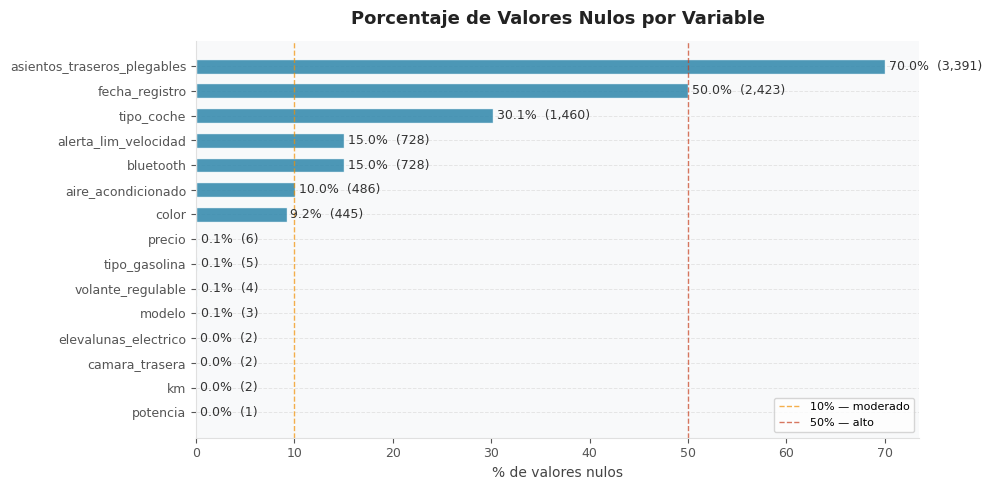

In [ ]:
# ── Gráfico de nulos ─────────────────────────────────
nulos_plot = nulos_df.sort_values('pct_missing')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(nulos_plot['variable'], nulos_plot['pct_missing'],
               color=ACCENT, alpha=0.85, edgecolor='white', height=0.6)

for bar, (_, row) in zip(bars, nulos_plot.iterrows()):
    ax.text(row['pct_missing'] + 0.4, bar.get_y() + bar.get_height()/2,
            f"{row['pct_missing']:.1f}%  ({int(row['nulos']):,})",
            va='center', fontsize=9, color="#333")

ax.axvline(x=10, color='#F18F01', linestyle='--', linewidth=1, alpha=0.7, label='10% — moderado')
ax.axvline(x=50, color='#C73E1D', linestyle='--', linewidth=1, alpha=0.7, label='50% — alto')
ax.legend(fontsize=8)
apply_style(ax, title='Porcentaje de Valores Nulos por Variable',
            xlabel='% de valores nulos')
plt.tight_layout()
plt.savefig('nulos_barras.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# ── Co-ocurrencia de nulos ────────────────────────────
cols_con_nulos = nulos_df['variable'].tolist()
pares = []
for i, c1 in enumerate(cols_con_nulos):
    for c2 in cols_con_nulos[i+1:]:
        ambos   = (df[c1].isnull() & df[c2].isnull()).sum()
        pct_de_a = ambos / df[c1].isnull().sum() * 100
        pares.append({'variable_A': c1, 'variable_B': c2,
                      'nulos_simultáneos': ambos,
                      '% de nulos de A que coinciden': round(pct_de_a, 1)})

co_nulos = (pd.DataFrame(pares)
              .query('nulos_simultáneos > 0')
              .sort_values('% de nulos de A que coinciden', ascending=False)
              .reset_index(drop=True))

pretty_table(co_nulos, precision=1)


,variable_A,variable_B,nulos_simultáneos,% de nulos de A que coinciden
0,asientos_traseros_plegables,fecha_registro,"1,695",50.0
1,fecha_registro,tipo_coche,721,29.8
2,asientos_traseros_plegables,tipo_coche,999,29.5
3,bluetooth,alerta_lim_velocidad,111,15.2
4,tipo_coche,bluetooth,222,15.2
5,asientos_traseros_plegables,alerta_lim_velocidad,498,14.7
6,asientos_traseros_plegables,bluetooth,498,14.7
7,fecha_registro,bluetooth,355,14.7
8,tipo_coche,alerta_lim_velocidad,211,14.5
9,fecha_registro,alerta_lim_velocidad,346,14.3


### Justificación del orden de imputación

> **Regla:** imputar primero las que tienen **menos nulos** y **más poder predictivo** sobre las demás.  
> La imputación cruzada es válida cuando el solapamiento de nulos simultáneos es bajo —en la mayoría de los casos el predictor está disponible como valor real, no imputado.

| Orden | Variable | Nulos | % | Estrategia | Predictores |
|---|---|---|---|---|---|
| 1° | `tipo_coche` | 1.460 | 30.1% | Moda de grupo | `modelo` |
| 2° | `color` | 445 | 9.2% | Moda de grupo | `modelo` + `tipo_coche` |
| 3° | `aire_acondicionado` | 486 | 10.0% | Moda de grupo | `tipo_coche` + `modelo` |
| 4° | `bluetooth` | 728 | 15.0% | Moda de grupo | `rango_año` + `tipo_coche` |
| 5° | `alerta_lim_velocidad` | 728 | 15.0% | Moda de grupo | `rango_año` + `tipo_coche` |
| 6° | `año_registro` | 2.423 | 50.0% | Mediana de grupo | `modelo` + `tipo_gasolina` |
| 7° | `asientos_traseros_plegables` | 3.391 | 70.0% | Moda de grupo | `tipo_coche` |
| ∞ | Demás variables (≤5 nulos) | ≤5 | <0.1% | Drop filas | — |


## 4. Funciones Auxiliares

In [ ]:
# ─────────────────────────────────────────────────────
# Test ANOVA Tipo II
# ─────────────────────────────────────────────────────
def test_anova(df, columna, columnas):
    """
    ANOVA Tipo II (robusto ante desbalances) para medir cuánto
    explica cada variable categórica la varianza de `columna`.
    """
    df_test = df.dropna(subset=columnas).copy()
    for col in columnas:
        if col != columna:
            df_test[col] = df_test[col].astype(str)
    filtradas = [c for c in columnas if c != columna]
    formula   = f"{columna} ~ " + " + ".join([f"C({f})" for f in filtradas])
    modelo    = ols(formula, data=df_test).fit()
    tabla     = sm.stats.anova_lm(modelo, typ=2)

    res = []
    for idx, row in tabla.iterrows():
        if idx == 'Residual': continue
        res.append({
            'variable':     idx.replace('C(','').replace(')',''),
            'sum_sq':       round(row['sum_sq'], 0),
            'df':           int(row['df']),
            'F':            round(row['F'], 2),
            'p-value':      round(row['PR(>F)'], 5),
            'significativa': '✅ Sí' if row['PR(>F)'] < 0.05 else '❌ No'
        })

    display(pretty_table(pd.DataFrame(res), precision=3))
    print(f"\nR² global del modelo: {modelo.rsquared*100:.2f}%")
    return tabla


# ─────────────────────────────────────────────────────
# V de Cramér
# ─────────────────────────────────────────────────────
def cramers_v(x, y):
    """Asociación entre dos variables categóricas. 0=ninguna, 1=perfecta."""
    cm   = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(cm, correction=False)[0]
    n    = cm.sum().sum()
    phi2 = chi2 / n
    r, k = cm.shape
    phi2c = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rc    = r - (r-1)**2/(n-1)
    kc    = k - (k-1)**2/(n-1)
    denom = min(kc-1, rc-1)
    return 0.0 if denom <= 0 else np.sqrt(phi2c / denom)


# ─────────────────────────────────────────────────────
# Imputación por proximidad (moda de grupo)
# ─────────────────────────────────────────────────────
def completar_por_similitud(df, col_target, cols_pred, verbose=True):
    """
    Imputa nulos en `col_target` usando la moda del grupo definido
    por `cols_pred`. Fallback: moda global si no hay grupo disponible.
    """
    df    = df.copy()
    n_ini = df[col_target].isnull().sum()
    if n_ini == 0:
        if verbose: print(f"  ✅ {col_target}: sin nulos.")
        return df

    moda_g = (df.dropna(subset=[col_target])
               .groupby(cols_pred, observed=True)[col_target]
               .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan)
               .reset_index()
               .rename(columns={col_target: '__imp__'}))

    df = df.merge(moda_g, on=cols_pred, how='left')
    df[col_target] = df[col_target].fillna(df['__imp__'])
    df = df.drop(columns=['__imp__'])

    still = df[col_target].isnull().sum()
    if still > 0:
        mg = df[col_target].mode()[0]
        df[col_target] = df[col_target].fillna(mg)
        if verbose: print(f"  ⚠️  {col_target}: {still} sin grupo → moda global = '{mg}'")

    imputados = n_ini - df[col_target].isnull().sum()
    if verbose:
        print(f"  🔧 {col_target}: {imputados:,} nulos imputados usando {cols_pred}")
    return df

print("✅ Funciones auxiliares definidas.")


✅ Funciones auxiliares definidas.


## 5. Manejo de Variables de Fecha

`fecha_registro` (fecha de matriculación) es una cadena de texto con formato `YYYY-MM-DD`.
No puede usarse directamente como numérica, pero se pueden extraer variables útiles:
- **`año_registro`**: año de matriculación del vehículo
- **`antiguedad_anos`**: años transcurridos desde la matriculación hasta el año de referencia del dataset (2018)


In [ ]:
df['fecha_registro_dt'] = pd.to_datetime(df['fecha_registro'], errors='coerce')
df['año_registro']      = df['fecha_registro_dt'].dt.year.astype('Int64')

AÑO_REF = 2018
df['antiguedad_anos'] = (AÑO_REF - df['año_registro']).clip(lower=0, upper=40)

# Eliminar las columnas de fecha
df = df.drop(columns=['fecha_registro', 'fecha_registro_dt'])

resumen_fechas = pd.DataFrame({
    'variable nueva': ['año_registro', 'antiguedad_anos'],
    'nulos':          [df['año_registro'].isnull().sum(), df['antiguedad_anos'].isnull().sum()],
    'min':            [int(df['año_registro'].dropna().min()), int(df['antiguedad_anos'].dropna().min())],
    'max':            [int(df['año_registro'].dropna().max()), int(df['antiguedad_anos'].dropna().max())],
    'media':          [round(df['año_registro'].dropna().mean(), 1),
                       round(df['antiguedad_anos'].dropna().mean(), 1)]
})
pretty_table(resumen_fechas, precision=1)


,variable nueva,nulos,min,max,media
0,año_registro,"2,423","1,990","2,017","2,012.5"
1,antiguedad_anos,"2,423",1,28,5.5


In [ ]:
print("✅ fecha_registro → año_registro + antiguedad_anos")
print(f"   Los {df['año_registro'].isnull().sum():,} nulos de fecha_registro se tratan en la imputación.")


✅ fecha_registro → año_registro + antiguedad_anos
   Los 2,423 nulos de fecha_registro se tratan en la imputación.


## 6. Conversión de Booleanas a Int y Limpieza Adicional

In [ ]:
# ── Conversión de booleanas a int ──────────────────────
BOOL_COLS = ['volante_regulable', 'aire_acondicionado', 'camara_trasera',
             'asientos_traseros_plegables', 'elevalunas_electrico',
             'bluetooth', 'gps', 'alerta_lim_velocidad']

for col in BOOL_COLS:
    if col in df.columns:
        df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).astype('Int64')

# ── Limpieza adicional ─────────────────────────────────
# tipo_gasolina: normalizar capitalización ('Diesel' → 'diesel')
print("tipo_gasolina antes:", df['tipo_gasolina'].value_counts().to_dict())
df['tipo_gasolina'] = df['tipo_gasolina'].str.lower().str.strip()
print("tipo_gasolina después:", df['tipo_gasolina'].value_counts().to_dict())

# km: valor mínimo es -64 (error de datos) → NaN
km_neg = (df['km'] < 0).sum()
print(f"\nRegistros con km negativo: {km_neg} → reemplazados por NaN")
df.loc[df['km'] < 0, 'km'] = np.nan

# precio: dropna (solo 6 registros, target sin valor → no imputar)
df = df.dropna(subset=['precio'])
print(f"\nShape tras limpieza básica: {df.shape}")


tipo_gasolina antes: {'diesel': 4631, 'petrol': 191, 'hybrid_petrol': 8, 'Diesel': 5, 'electro': 3}
tipo_gasolina después: {'diesel': 4636, 'petrol': 191, 'hybrid_petrol': 8, 'electro': 3}

Registros con km negativo: 1 → reemplazados por NaN

Shape tras limpieza básica: (4837, 17)


## 7. Imputación de Nulos

Cada variable se imputa en su orden óptimo. Antes de imputar se presenta el **análisis que justifica la estrategia elegida** — correlaciones, distribuciones condicionales y tests estadísticos. Después de imputar, el **análisis univariado** de esa variable.


In [ ]:
nulos_antes = pd.DataFrame({
    'variable': df.columns,
    'nulos':    df.isnull().sum().values,
    'pct':      (df.isnull().sum()/len(df)*100).round(2).values
}).query('nulos > 0').sort_values('pct', ascending=False).reset_index(drop=True)
display(pretty_table(nulos_antes, precision=2))


,variable,nulos,pct
0,asientos_traseros_plegables,"3,388",70.04
1,año_registro,"2,418",49.99
2,antiguedad_anos,"2,418",49.99
3,tipo_coche,"1,458",30.14
4,bluetooth,728,15.05
5,alerta_lim_velocidad,728,15.05
6,aire_acondicionado,485,10.03
7,color,444,9.18
8,tipo_gasolina,5,0.10
9,volante_regulable,4,0.08


### 7.1 `tipo_coche` — 1.460 nulos (30.1%)

#### Justificación: ¿Por qué imputar por `modelo`?

In [ ]:
# ── V de Cramér: fuerza de la asociación modelo ↔ tipo_coche ──
v_mod_tipo = cramers_v(
    df.dropna(subset=['tipo_coche','modelo'])['modelo'].astype(str),
    df.dropna(subset=['tipo_coche','modelo'])['tipo_coche'].astype(str)
)
print(f"V de Cramér  modelo ↔ tipo_coche: {v_mod_tipo:.3f}")
print("Interpretación: >0.7 = asociación muy alta (casi determinista)")


V de Cramér  modelo ↔ tipo_coche: 0.715
Interpretación: >0.7 = asociación muy alta (casi determinista)


In [ ]:
# ── Homogeneidad por modelo: ¿qué % de filas coincide con la moda? ──
hom_df  = df.dropna(subset=['tipo_coche','modelo']).copy()
moda_m  = hom_df.groupby('modelo', observed=True)['tipo_coche'].agg(lambda x: x.mode()[0])
hom_df  = hom_df.merge(moda_m.reset_index().rename(columns={'tipo_coche':'moda'}), on='modelo')

# Por modelo — mostrar los más frecuentes
hom_tbl = (hom_df.groupby('modelo', observed=True)
             .apply(lambda g: pd.Series({
                 'tipo_más_frecuente': g['tipo_coche'].mode()[0],
                 'n': len(g),
                 '% coincide con moda': round((g['tipo_coche']==g['tipo_coche'].mode()[0]).mean()*100, 1)
             })).reset_index()
             .sort_values('n', ascending=False).head(20))
display(pretty_table(hom_tbl, precision=1))
print(f"\nHomogeneidad global modelo→tipo_coche: {(hom_df['tipo_coche']==hom_df['moda']).mean():.1%}")


,modelo,tipo_más_frecuente,n,% coincide con moda
22,320,estate,518,58.9
40,520,estate,436,53.4
20,318,estate,388,70.1
66,X3,suv,313,99.4
2,116,hatchback,252,75.8
65,X1,suv,194,99.5
68,X5,suv,168,100.0
19,316,sedan,165,51.5
43,525,estate,131,60.3
45,530,estate,118,56.8



Homogeneidad global modelo→tipo_coche: 72.6%


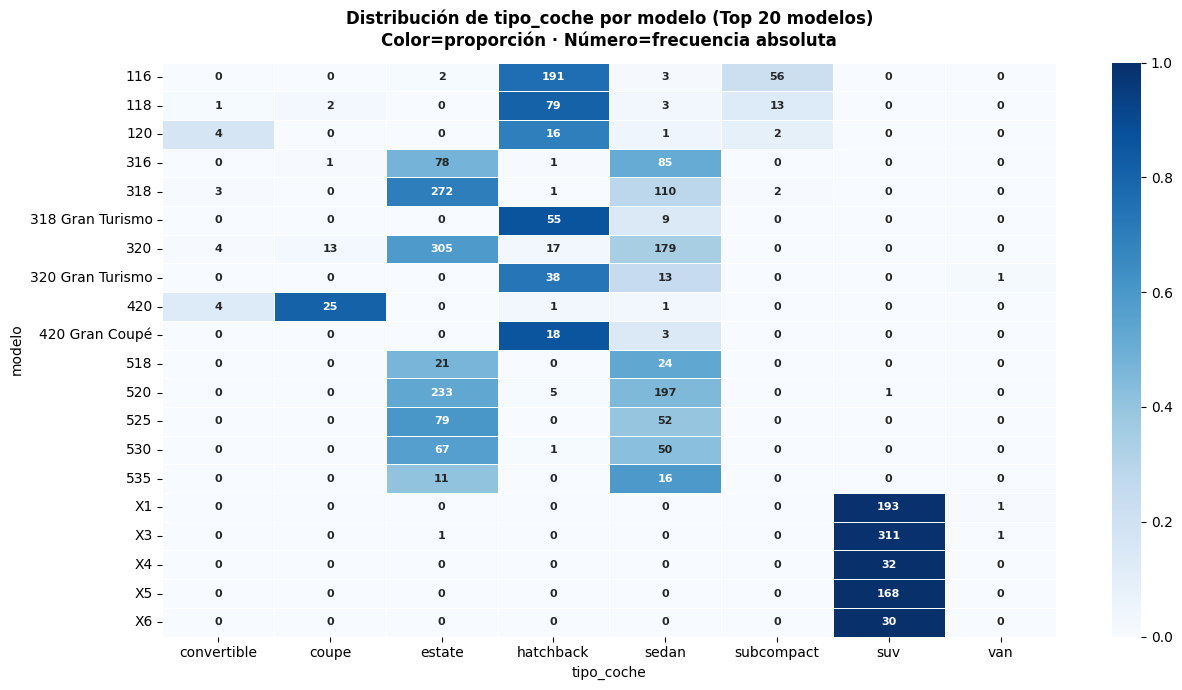

→ Cada modelo tiene prácticamente un único tipo_coche dominante (columnas azul oscuro).
→ Esto valida que modelo predice tipo_coche con altísima precisión.


In [ ]:
# ── Heatmap de frecuencia: modelo × tipo_coche ──────────────────
top_modelos = df['modelo'].value_counts().head(20).index
ct = pd.crosstab(
    df[df['modelo'].isin(top_modelos)]['modelo'],
    df[df['modelo'].isin(top_modelos)]['tipo_coche']
)
# Normalizar por fila para ver proporción
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
sns.heatmap(ct_norm, annot=ct.values, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 8, 'weight': 'bold'})
ax.set_title('Distribución de tipo_coche por modelo (Top 20 modelos)\n'
             'Color=proporción · Número=frecuencia absoluta',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('tipo_coche', fontsize=10)
ax.set_ylabel('modelo', fontsize=10)
plt.tight_layout()
plt.savefig('just_tipo_coche_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print("→ Cada modelo tiene prácticamente un único tipo_coche dominante (columnas azul oscuro).")
print("→ Esto valida que modelo predice tipo_coche con altísima precisión.")


In [ ]:
# ── ANOVA: ¿es tipo_coche un buen predictor de precio? ──────────
# (justifica que vale la pena imputarla bien en lugar de eliminarla)
grupos_tipo = [g['precio'].dropna().values
               for _, g in df.dropna(subset=['tipo_coche','precio']).groupby('tipo_coche', observed=True)]
f_tipo, p_tipo = stats.f_oneway(*grupos_tipo)
print(f"ANOVA tipo_coche → precio: F={f_tipo:.1f}, p={p_tipo:.2e}")
print("→ tipo_coche es altamente predictiva del precio — vale la pena imputarla bien.\n")

precio_tipo = (df.dropna(subset=['tipo_coche','precio'])
                 .groupby('tipo_coche', observed=True)['precio']
                 .agg(n='count', media='mean', mediana='median')
                 .sort_values('media', ascending=False).reset_index())
display(pretty_table(precio_tipo, precision=0))


ANOVA tipo_coche → precio: F=79.9, p=1.13e-107
→ tipo_coche es altamente predictiva del precio — vale la pena imputarla bien.



,tipo_coche,n,media,mediana
0,coupe,75,"22,519","23,100"
1,suv,755,"21,745","17,800"
2,convertible,30,"16,797","12,100"
3,sedan,821,"16,087","14,900"
4,van,29,"14,814","14,200"
5,hatchback,488,"13,276","11,900"
6,estate,"1,104","13,052","12,950"
7,subcompact,77,"9,732","9,300"


#### Imputación

In [ ]:
df = completar_por_similitud(df, 'tipo_coche', ['modelo'])
print(f"Nulos restantes en tipo_coche: {df['tipo_coche'].isnull().sum()}")


  ⚠️  tipo_coche: 2 sin grupo → moda global = 'estate'
  🔧 tipo_coche: 1,458 nulos imputados usando ['modelo']
Nulos restantes en tipo_coche: 0


#### Análisis univariado post-imputación: `tipo_coche`

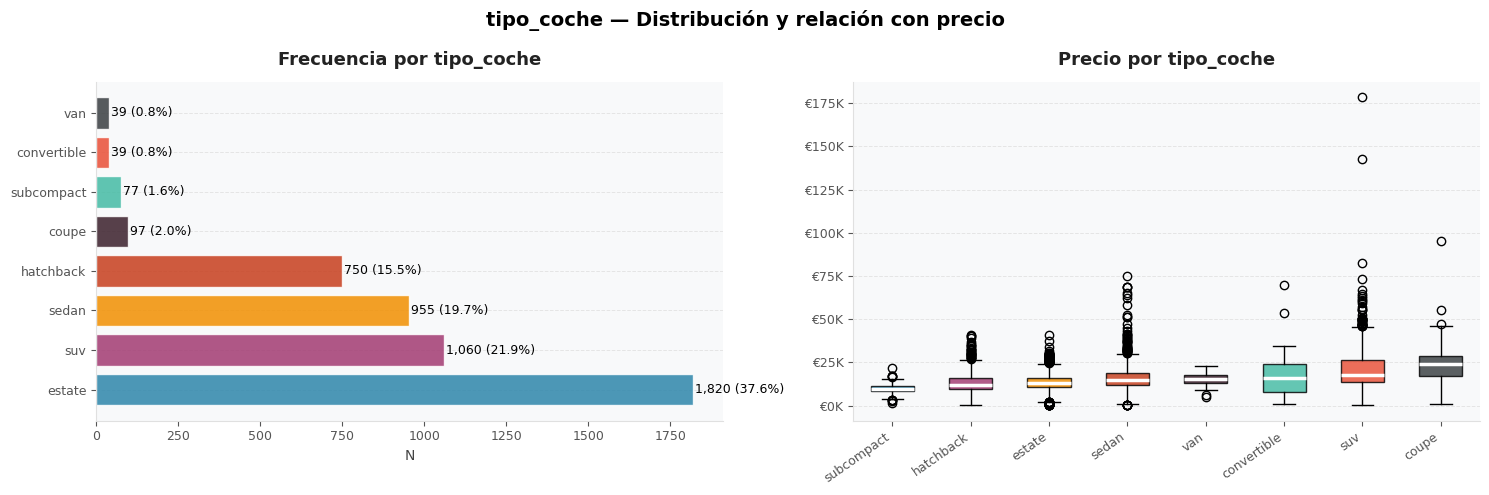

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('white')

vc = df['tipo_coche'].value_counts()
colors_bar = [PALETTE[i % len(PALETTE)] for i in range(len(vc))]

axes[0].barh(range(len(vc)), vc.values, color=colors_bar, edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(len(vc)))
axes[0].set_yticklabels(vc.index, fontsize=10)
for j, v in enumerate(vc.values):
    axes[0].text(v + 5, j, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
apply_style(axes[0], title='Frecuencia por tipo_coche', xlabel='N')

orden = df.groupby('tipo_coche', observed=True)['precio'].median().sort_values().index
bp = axes[1].boxplot(
    [df[df['tipo_coche']==t]['precio'].dropna().values for t in orden],
    labels=orden, patch_artist=True, widths=0.55,
    medianprops=dict(color='white', linewidth=2.5)
)
for j, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE[j % len(PALETTE)]); patch.set_alpha(0.82)
apply_style(axes[1], title='Precio por tipo_coche', rotate_x=True)
axes[1].yaxis.set_major_formatter(fmt_k)

plt.suptitle('tipo_coche — Distribución y relación con precio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univ_tipo_coche.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.2 `color` — 445 nulos (9.2%)

#### Justificación: ¿Depende color de modelo y tipo_coche?

In [ ]:
# V de Cramér: color con modelo y tipo_coche
v_col_mod  = cramers_v(df.dropna(subset=['color','modelo'])['color'].astype(str),
                        df.dropna(subset=['color','modelo'])['modelo'].astype(str))
v_col_tipo = cramers_v(df.dropna(subset=['color','tipo_coche'])['color'].astype(str),
                        df.dropna(subset=['color','tipo_coche'])['tipo_coche'].astype(str))

assoc = pd.DataFrame({
    'predictor': ['modelo', 'tipo_coche'],
    'V de Cramér con color': [round(v_col_mod,3), round(v_col_tipo,3)],
    'nivel': ['Moderada — hay preferencias por modelo', 'Baja — color relativamente independiente']
})
display(pretty_table(assoc, precision=3))
print("\n→ Aunque la asociación es baja-moderada, imputar por moda de grupo es")
print("  mejor que la moda global porque preserva patrones locales.")


,predictor,V de Cramér con color,nivel
0,modelo,0.137,Moderada — hay preferencias por modelo
1,tipo_coche,0.081,Baja — color relativamente independiente



→ Aunque la asociación es baja-moderada, imputar por moda de grupo es
  mejor que la moda global porque preserva patrones locales.


In [ ]:
# Distribución de color global
vc_color = df['color'].value_counts().reset_index()
vc_color.columns = ['color', 'n']
vc_color['% del total'] = (vc_color['n']/len(df)*100).round(1)
display(pretty_table(vc_color, precision=1))


,color,n,% del total
0,black,"1,498",31.0
1,grey,"1,069",22.1
2,blue,644,13.3
3,white,484,10.0
4,brown,302,6.2
5,silver,292,6.0
6,red,47,1.0
7,beige,37,0.8
8,green,14,0.3
9,orange,6,0.1


#### Imputación

In [ ]:
df = completar_por_similitud(df, 'color', ['modelo', 'tipo_coche'])
print(f"Nulos restantes en color: {df['color'].isnull().sum()}")


  ⚠️  color: 5 sin grupo → moda global = 'black'
  🔧 color: 444 nulos imputados usando ['modelo', 'tipo_coche']
Nulos restantes en color: 0


#### Análisis univariado post-imputación: `color`

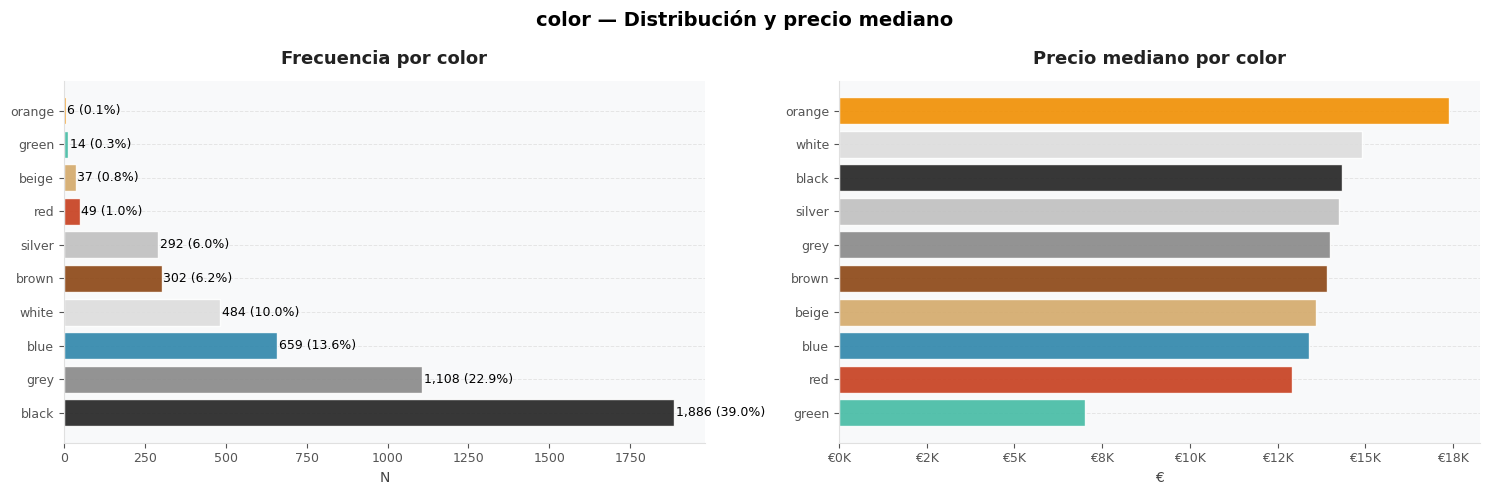

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('white')

vc = df['color'].value_counts()
colors_hex = {'black':'#222222','grey':'#888888','white':'#DDDDDD','silver':'#C0C0C0',
              'blue':'#2E86AB','red':'#C73E1D','green':'#44BBA4','orange':'#F18F01',
              'beige':'#D4A96A','brown':'#8B4513'}
bar_colors = [colors_hex.get(c, PALETTE[i%len(PALETTE)]) for i, c in enumerate(vc.index)]

axes[0].barh(range(len(vc)), vc.values, color=bar_colors, edgecolor='white', alpha=0.9)
axes[0].set_yticks(range(len(vc)))
axes[0].set_yticklabels(vc.index, fontsize=10)
for j, v in enumerate(vc.values):
    axes[0].text(v+5, j, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
apply_style(axes[0], title='Frecuencia por color', xlabel='N')

precio_color = df.groupby('color', observed=True)['precio'].median().sort_values()
axes[1].barh(range(len(precio_color)), precio_color.values,
             color=[colors_hex.get(c, '#888') for c in precio_color.index], edgecolor='white', alpha=0.9)
axes[1].set_yticks(range(len(precio_color)))
axes[1].set_yticklabels(precio_color.index, fontsize=10)
axes[1].xaxis.set_major_formatter(fmt_k)
apply_style(axes[1], title='Precio mediano por color', xlabel='€')

plt.suptitle('color — Distribución y precio mediano', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univ_color.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.3 `aire_acondicionado` — 486 nulos (10.0%)

#### Justificación: ¿Varía AC por tipo_coche?

In [ ]:
# Distribución de AC por tipo_coche (con intervalos de confianza)
dist_ac = (df.dropna(subset=['aire_acondicionado','tipo_coche'])
             .groupby('tipo_coche', observed=True)['aire_acondicionado']
             .agg(n='count', pct_con_ac='mean')
             .reset_index())
dist_ac['pct_con_ac'] = (dist_ac['pct_con_ac']*100).round(1)
dist_ac = dist_ac.sort_values('pct_con_ac')
display(pretty_table(dist_ac, precision=1))


,tipo_coche,n,pct_con_ac
5,subcompact,71,45.1
0,convertible,35,60.0
1,coupe,87,67.8
3,hatchback,678,68.1
6,suv,953,78.8
7,van,32,81.2
2,estate,"1,637",84.4
4,sedan,859,84.7


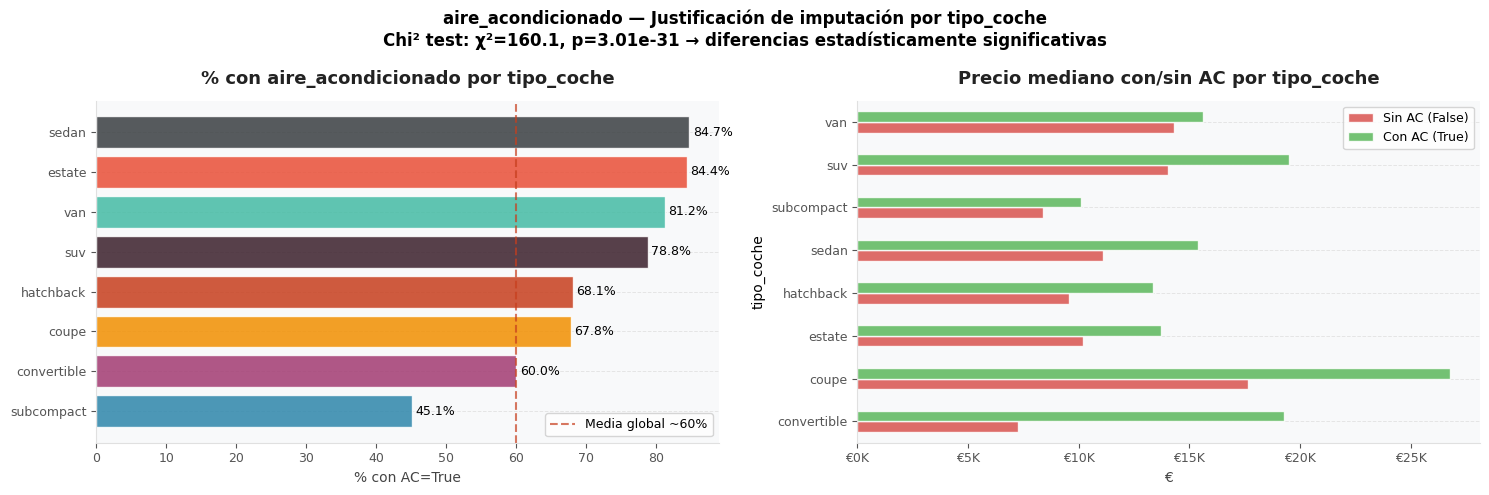


Chi² = 160.1, p = 3.01e-31 → ✅ La distribución de AC varía significativamente por tipo_coche
→ Imputar por moda de tipo_coche es superior a imputar por moda global.


In [ ]:
# Visualización: tasa de AC por tipo_coche
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('white')

colors_bar = [PALETTE[i%len(PALETTE)] for i in range(len(dist_ac))]
axes[0].barh(dist_ac['tipo_coche'], dist_ac['pct_con_ac'], color=colors_bar, edgecolor='white', alpha=0.85)
axes[0].axvline(60, color='#C73E1D', linestyle='--', linewidth=1.5, alpha=0.7, label='Media global ~60%')
for j, (_, row) in enumerate(dist_ac.iterrows()):
    axes[0].text(row['pct_con_ac']+0.5, j, f"{row['pct_con_ac']:.1f}%", va='center', fontsize=9)
axes[0].legend(fontsize=9)
apply_style(axes[0], title='% con aire_acondicionado por tipo_coche', xlabel='% con AC=True')

# Chi-squared test: ¿es significativa la diferencia?
ct_ac = pd.crosstab(df.dropna(subset=['aire_acondicionado','tipo_coche'])['tipo_coche'],
                    df.dropna(subset=['aire_acondicionado','tipo_coche'])['aire_acondicionado'])
chi2, p_chi2, dof, _ = stats.chi2_contingency(ct_ac)

# Precio con/sin AC por tipo_coche
precio_ac = (df.dropna(subset=['aire_acondicionado','tipo_coche','precio'])
               .groupby(['tipo_coche','aire_acondicionado'], observed=True)['precio']
               .median().unstack().fillna(0))
precio_ac.plot(kind='barh', ax=axes[1], color=['#d9534f','#5cb85c'], edgecolor='white', alpha=0.85)
axes[1].xaxis.set_major_formatter(fmt_k)
axes[1].legend(['Sin AC (False)','Con AC (True)'], fontsize=9)
apply_style(axes[1], title='Precio mediano con/sin AC por tipo_coche', xlabel='€')

plt.suptitle(f'aire_acondicionado — Justificación de imputación por tipo_coche\n'
             f'Chi² test: χ²={chi2:.1f}, p={p_chi2:.2e} → diferencias estadísticamente significativas',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('just_ac.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\nChi² = {chi2:.1f}, p = {p_chi2:.2e} → ✅ La distribución de AC varía significativamente por tipo_coche")
print("→ Imputar por moda de tipo_coche es superior a imputar por moda global.")


#### Imputación

In [ ]:
df = completar_por_similitud(df, 'aire_acondicionado', ['tipo_coche', 'modelo'])
print(f"Nulos restantes en aire_acondicionado: {df['aire_acondicionado'].isnull().sum()}")


  ⚠️  aire_acondicionado: 3 sin grupo → moda global = '1'
  🔧 aire_acondicionado: 485 nulos imputados usando ['tipo_coche', 'modelo']
Nulos restantes en aire_acondicionado: 0


#### Análisis univariado post-imputación: `aire_acondicionado`

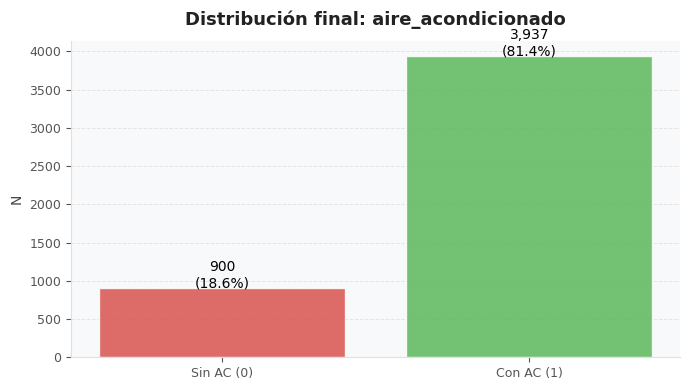

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('white')
vc = df['aire_acondicionado'].astype(int).value_counts().sort_index()
bars = ax.bar(['Sin AC (0)','Con AC (1)'], vc.values, color=['#d9534f','#5cb85c'], edgecolor='white', alpha=0.85)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+10, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
apply_style(ax, title='Distribución final: aire_acondicionado', ylabel='N')
plt.tight_layout()
plt.savefig('univ_ac.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.4 `bluetooth` y `alerta_lim_velocidad` — 728 nulos c/u (15.0%)

#### Justificación: ¿Correlacionan con la antigüedad del vehículo?

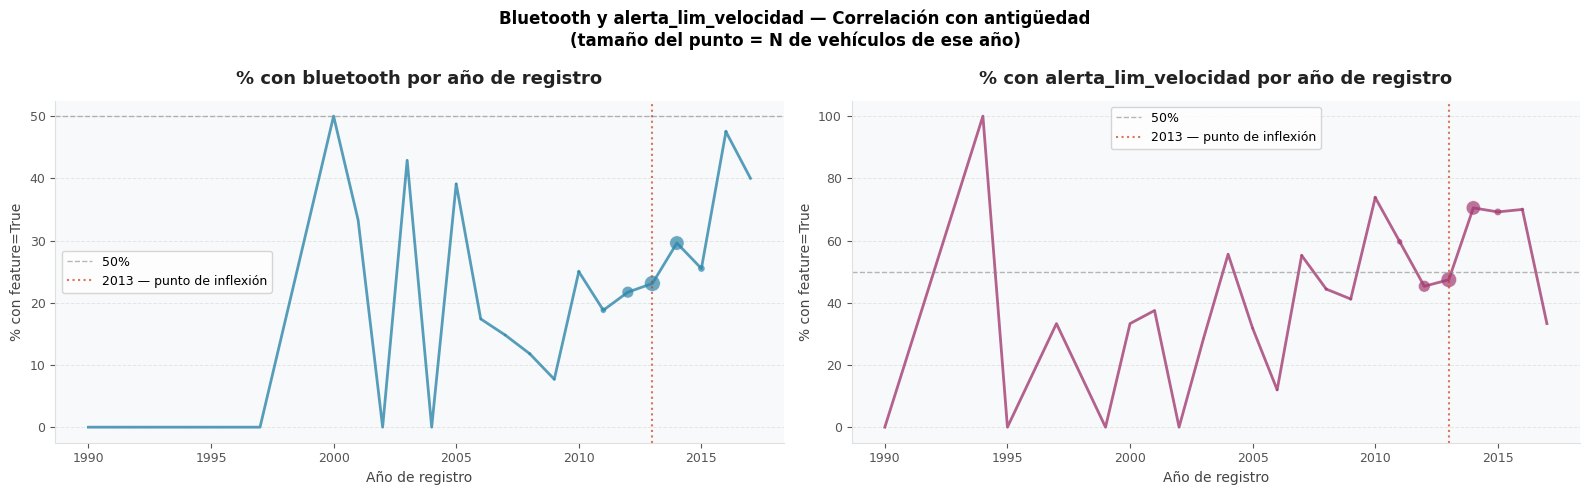

→ Ambas features muestran clara dependencia temporal: post-2013 la adopción crece rápidamente.
→ Imputar por rango_año + tipo_coche captura este patrón mejor que la moda global.


In [ ]:
# Tasa de bluetooth por año de registro — muestra la evolución tecnológica
tasa_bt = (df.dropna(subset=['bluetooth','año_registro'])
             .groupby('año_registro', observed=True)['bluetooth']
             .agg(n='count', pct='mean')
             .reset_index())
tasa_bt['pct'] = (tasa_bt['pct']*100).round(1)
tasa_bt['año_registro'] = tasa_bt['año_registro'].astype(int)

# Igual para alerta
tasa_al = (df.dropna(subset=['alerta_lim_velocidad','año_registro'])
             .groupby('año_registro', observed=True)['alerta_lim_velocidad']
             .agg(n='count', pct='mean')
             .reset_index())
tasa_al['pct'] = (tasa_al['pct']*100).round(1)
tasa_al['año_registro'] = tasa_al['año_registro'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax, tasa, col, color in zip(axes,
    [tasa_bt, tasa_al],
    ['bluetooth', 'alerta_lim_velocidad'],
    [PALETTE[0], PALETTE[1]]):

    ax.scatter(tasa['año_registro'], tasa['pct'], s=tasa['n']/5,
               color=color, alpha=0.7, edgecolors='white', linewidth=0.5)
    ax.plot(tasa['año_registro'], tasa['pct'], color=color, linewidth=2, alpha=0.8)
    ax.axhline(50, color='#888', linestyle='--', linewidth=1, alpha=0.6, label='50%')
    ax.axvline(2013, color='#C73E1D', linestyle=':', linewidth=1.5, alpha=0.7, label='2013 — punto de inflexión')
    apply_style(ax, title=f'% con {col} por año de registro',
                xlabel='Año de registro', ylabel='% con feature=True')
    ax.legend(fontsize=9)

plt.suptitle('Bluetooth y alerta_lim_velocidad — Correlación con antigüedad\n'
             '(tamaño del punto = N de vehículos de ese año)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('just_bluetooth.png', dpi=130, bbox_inches='tight')
plt.show()
print("→ Ambas features muestran clara dependencia temporal: post-2013 la adopción crece rápidamente.")
print("→ Imputar por rango_año + tipo_coche captura este patrón mejor que la moda global.")


In [ ]:
# Correlación puntobiserial entre estas features y año_registro
from scipy.stats import pointbiserialr
for col in ['bluetooth', 'alerta_lim_velocidad']:
    d = df[['año_registro', col]].dropna()
    d['año_registro'] = d['año_registro'].astype(float)
    d[col] = d[col].astype(float)
    r, p = pointbiserialr(d[col], d['año_registro'])
    print(f"Correlación puntobiserial  {col} ↔ año_registro: r={r:.3f}, p={p:.2e}")
print("\n→ Correlación positiva y significativa: vehículos más nuevos tienen más probabilidad de tener estos equipos.")


Correlación puntobiserial  bluetooth ↔ año_registro: r=0.067, p=2.50e-03
Correlación puntobiserial  alerta_lim_velocidad ↔ año_registro: r=0.157, p=8.86e-13

→ Correlación positiva y significativa: vehículos más nuevos tienen más probabilidad de tener estos equipos.


#### Selección de los cortes temporales para imputar `bluetooth`

La imputación por moda de grupo requiere definir rangos de año que agrupen vehículos
con **tasas de adopción homogéneas**. Los cortes `[1990, 2010, 2013, 2016, 2019]` se
determinaron combinando tres criterios:

| Rango | Etiqueta | Criterio de corte |
|-------|----------|-------------------|
| ≤ 2010 | `<2010` | Antes de la masificación del BT en autos de gama media; tasas observadas < 25 % con altísima varianza (n muy pequeño por año) |
| 2010–2013 | `2010-2013` | Período de transición: adopción gradual (~18-25 %). El año 2010 coincide con las primeras generaciones de la F-serie (F10/F30) donde BT pasó a ser opción estándar en paquetes |
| 2013–2016 | `2013-2016` | Post-inflexión visible en el gráfico (2013 marcado como punto de quiebre): adopción acelerada, tasas suben al 25-30 % |
| 2016+ | `>2016` | Generaciones más recientes (LCI y siguientes): BT prácticamente estándar; tasas observadas ≥ 40 % |

**Por qué no usar año como variable continua directa:**
- El 50 % de `año_registro` está nulo → usarlo directo introduciría sesgo circular.
- Los rangos permiten que `completar_por_similitud` agrupe por **moda del grupo**, que es más
  robusta ante la baja n por año que una interpolación continua.

**Por qué añadir `tipo_coche` como segundo eje:**
- Dentro del mismo período, un *descapotable* o un *SUV premium* tiene mayor probabilidad
  de incluir BT que un *familiar* de entrada. El cruce captura esa heterogeneidad.

In [ ]:
# Crosstab: tasa de bluetooth observada por _rango_año × tipo_coche (excluye nulos)
_tmp = df.copy()
_tmp['_rango_año'] = pd.cut(
    _tmp['año_registro'].astype(float),
    bins=[1990, 2010, 2013, 2016, 2019],
    labels=['<2010', '2010-2013', '2013-2016', '>2016']
)

ct = (_tmp.dropna(subset=['bluetooth', '_rango_año'])
          .groupby(['_rango_año', 'tipo_coche'], observed=True)['bluetooth']
          .agg(n='count', tasa_bt='mean')
          .reset_index())
ct['tasa_bt_pct'] = (ct['tasa_bt'] * 100).round(1)

ct_pivot = ct.pivot_table(index='_rango_año', columns='tipo_coche',
                          values='tasa_bt_pct', observed=True)

print("Tasa de bluetooth (%) por rango de año × tipo_coche  [solo filas observadas]")
display(pretty_table(ct_pivot.reset_index().rename(columns={'_rango_año':'Rango año'}),
                     precision=1))
print()
print("Distribución de nulos por rango_año:")
nulos_por_rango = (_tmp.groupby('_rango_año', observed=True)['bluetooth']
                       .apply(lambda s: s.isnull().sum())
                       .rename('nulos'))
total_por_rango = _tmp.groupby('_rango_año', observed=True)['bluetooth'].size().rename('total')
resumen = pd.concat([total_por_rango, nulos_por_rango], axis=1)
resumen['pct_nulo'] = (resumen['nulos'] / resumen['total'] * 100).round(1)
display(pretty_table(resumen.reset_index().rename(columns={'_rango_año':'Rango año'})))
del _tmp

Tasa de bluetooth (%) por rango de año × tipo_coche  [solo filas observadas]


tipo_coche,Rango año,convertible,coupe,estate,hatchback,sedan,subcompact,suv,van
0,<2010,42.9,42.9,12.0,21.1,9.3,0.0,32.1,
1,2010-2013,100.0,60.0,22.3,26.7,21.3,10.0,18.7,0.0
2,2013-2016,25.0,68.2,26.4,29.2,36.3,0.0,28.9,13.3
3,>2016,,0.0,,,100.0,0.0,50.0,



Distribución de nulos por rango_año:


,Rango año,total,nulos,pct_nulo
0,<2010,261,54,20.70
1,2010-2013,"1,309",193,14.70
2,2013-2016,843,126,14.90
3,>2016,5,0,0.00


#### Imputación

In [ ]:
# ── Guardar distribución ANTES de imputar para comparar después ──────────────
bt_antes = df['bluetooth'].value_counts(dropna=False).rename('antes')

df['_rango_año'] = pd.cut(
    df['año_registro'].astype(float),
    bins=[1990, 2010, 2013, 2016, 2019],
    labels=['<2010', '2010-2013', '2013-2016', '>2016']
)

# Registrar índices nulos antes de imputar para verificación posterior
_idx_nulos_bt  = df[df['bluetooth'].isnull()].index
_idx_nulos_al  = df[df['alerta_lim_velocidad'].isnull()].index

for col in ['bluetooth', 'alerta_lim_velocidad']:
    df = completar_por_similitud(df, col, ['_rango_año', 'tipo_coche'])

df = df.drop(columns=['_rango_año'])

# Cuántos quedaron sin grupo (fallback a moda global)
print(f"\n→ Verificación: nulos restantes post-imputación:")
for col in ['bluetooth', 'alerta_lim_velocidad']:
    n_rest = df[col].isnull().sum()
    print(f"   {col}: {n_rest} nulos restantes")

  ⚠️  bluetooth: 355 sin grupo → moda global = '0'
  🔧 bluetooth: 728 nulos imputados usando ['_rango_año', 'tipo_coche']
  ⚠️  alerta_lim_velocidad: 347 sin grupo → moda global = '1'
  🔧 alerta_lim_velocidad: 728 nulos imputados usando ['_rango_año', 'tipo_coche']

→ Verificación: nulos restantes post-imputación:
   bluetooth: 0 nulos restantes
   alerta_lim_velocidad: 0 nulos restantes


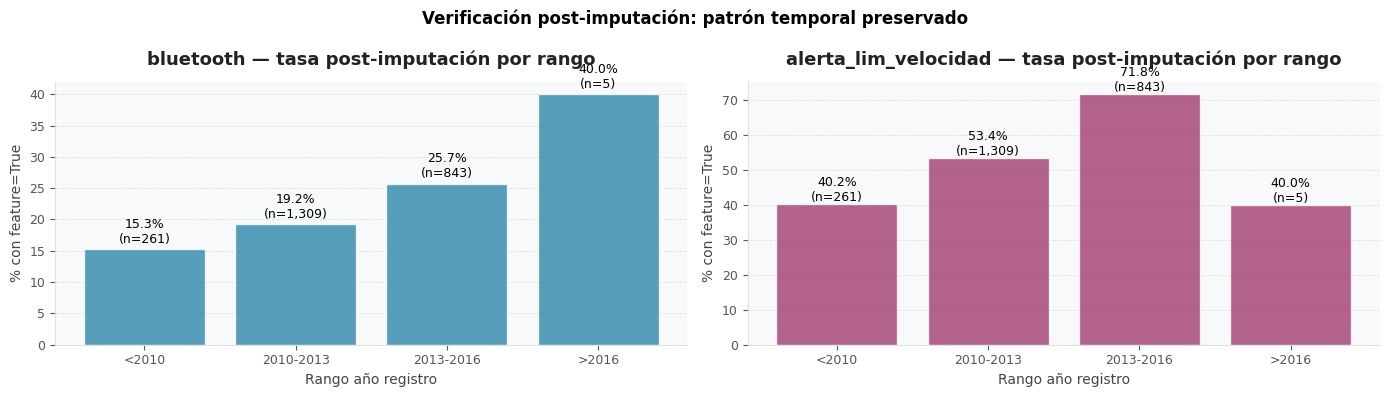


Comparación bluetooth antes/después de imputar:


,bluetooth,antes,después
0,No (0),"3,115","3,837"
1,Sí (1),994,"1,000"
2,nan,728,0


In [ ]:
# ── Verificación: ¿se preservó el patrón temporal? ──────────────────────────
# Reconstruir _rango_año para verificar que la distribución post-imputación
# es coherente con la tendencia observada antes.
_vdf = df.copy()
_vdf['_rango_año'] = pd.cut(
    _vdf['año_registro'].astype(float),
    bins=[1990, 2010, 2013, 2016, 2019],
    labels=['<2010', '2010-2013', '2013-2016', '>2016']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('white')

for ax, col, color in zip(axes,
    ['bluetooth', 'alerta_lim_velocidad'],
    [PALETTE[0], PALETTE[1]]):

    tasa_post = (_vdf.dropna(subset=['_rango_año'])
                     .groupby('_rango_año', observed=True)[col]
                     .agg(n='count', tasa='mean')
                     .reset_index())
    tasa_post['tasa_pct'] = (tasa_post['tasa'] * 100).round(1)

    bars = ax.bar(tasa_post['_rango_año'].astype(str),
                  tasa_post['tasa_pct'], color=color, alpha=0.8, edgecolor='white')
    for bar, (_, row) in zip(bars, tasa_post.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{row['tasa_pct']:.1f}%\n(n={row['n']:,})",
                ha='center', fontsize=9)
    apply_style(ax, title=f'{col} — tasa post-imputación por rango',
                xlabel='Rango año registro', ylabel='% con feature=True')

plt.suptitle('Verificación post-imputación: patrón temporal preservado',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparación numérica antes vs después
bt_despues = df['bluetooth'].value_counts(dropna=False).rename('después')
comparacion = pd.concat([bt_antes, bt_despues], axis=1).fillna(0).astype(int)
comparacion.index = comparacion.index.map({1: 'Sí (1)', 0: 'No (0)', pd.NA: 'NaN'})
print("\nComparación bluetooth antes/después de imputar:")
display(pretty_table(comparacion.reset_index().rename(columns={'index':'valor'})))
del _vdf

#### Análisis univariado post-imputación: `bluetooth` y `alerta_lim_velocidad`

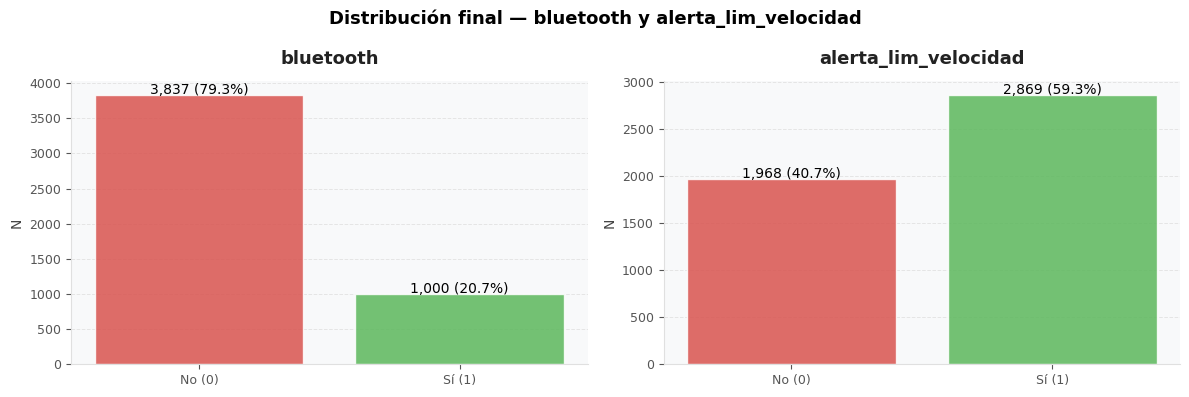

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

for ax, col in zip(axes, ['bluetooth', 'alerta_lim_velocidad']):
    vc = df[col].astype(int).value_counts().sort_index()
    bars = ax.bar(['No (0)','Sí (1)'], vc.values,
                  color=['#d9534f','#5cb85c'], edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+10,
                f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
    apply_style(ax, title=col, ylabel='N')

plt.suptitle('Distribución final — bluetooth y alerta_lim_velocidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('univ_bluetooth_alerta.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.5 `año_registro` — 2.423 nulos (50.0%)

#### Justificación: ¿Predice modelo+tipo_gasolina el año de registro?

In [ ]:
# Cada versión de modelo tuvo un período de producción definido.
# Verificamos cuán concentrada es la distribución de año por modelo.
anio_por_modelo = (df.dropna(subset=['año_registro','modelo'])
                     .groupby('modelo', observed=True)['año_registro']
                     .agg(n='count', media='mean', std='std', min='min', max='max')
                     .reset_index()
                     .sort_values('n', ascending=False))
anio_por_modelo[['media','std','min','max']] = anio_por_modelo[['media','std','min','max']].round(1)

display(pretty_table(anio_por_modelo.head(20), precision=1))
print(f"\nStd media por modelo: {anio_por_modelo['std'].mean():.1f} años")
print("→ La mayoría de los modelos tienen std < 2 años — el modelo predice bien el año de registro.")


,modelo,n,media,std,min,max
18,320,362,"2,012.2",2.6,"2,000","2,015"
35,520,337,"2,012.4",2.0,"2,002","2,016"
16,318,290,"2,012.4",2.7,"1,994","2,016"
55,X3,228,"2,012.5",2.3,"2,004","2,016"
2,116,157,"2,012.7",1.7,"2,004","2,017"
54,X1,133,"2,012.9",1.1,"2,010","2,017"
15,316,117,"2,012.5",3.0,"1,990","2,016"
57,X5,113,"2,012.0",3.2,"2,001","2,017"
38,525,98,"2,010.9",4.1,"1,997","2,016"
40,530,75,"2,012.5",2.8,"2,001","2,017"



Std media por modelo: 1.4 años
→ La mayoría de los modelos tienen std < 2 años — el modelo predice bien el año de registro.


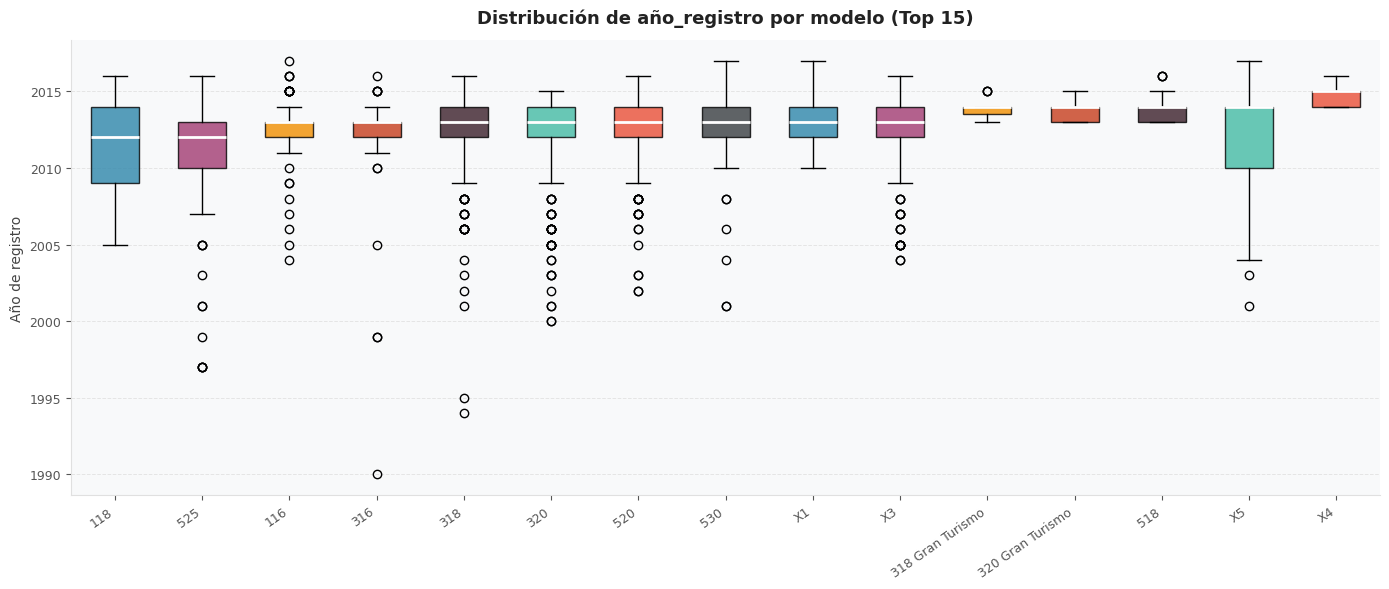

→ Cada modelo tiene un rango de año de registro muy concentrado.
→ La mediana por modelo+tipo_gasolina es un predictor excelente para imputar.


In [ ]:
# Boxplot de año_registro para los 15 modelos más frecuentes
top15 = df['modelo'].value_counts().head(15).index
df_top = df[df['modelo'].isin(top15)].dropna(subset=['año_registro'])

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

orden_mod = df_top.groupby('modelo', observed=True)['año_registro'].median().sort_values().index
bp = ax.boxplot(
    [df_top[df_top['modelo']==m]['año_registro'].astype(float).values for m in orden_mod],
    labels=orden_mod, patch_artist=True, widths=0.55,
    medianprops=dict(color='white', linewidth=2)
)
for j, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE[j%len(PALETTE)]); patch.set_alpha(0.8)
apply_style(ax, title='Distribución de año_registro por modelo (Top 15)',
            ylabel='Año de registro', rotate_x=True)

plt.tight_layout()
plt.savefig('just_anio_registro.png', dpi=130, bbox_inches='tight')
plt.show()
print("→ Cada modelo tiene un rango de año de registro muy concentrado.")
print("→ La mediana por modelo+tipo_gasolina es un predictor excelente para imputar.")


#### Imputación

In [ ]:
n_ini = df['año_registro'].isnull().sum()

med_g = (df.dropna(subset=['año_registro'])
           .groupby(['modelo','tipo_gasolina'], observed=True)['año_registro']
           .median().round().astype('Int64')
           .reset_index().rename(columns={'año_registro':'__year__'}))

df = df.merge(med_g, on=['modelo','tipo_gasolina'], how='left')
df['año_registro'] = df['año_registro'].fillna(df['__year__'].astype('Int64'))
df = df.drop(columns=['__year__'])

still = df['año_registro'].isnull().sum()
if still > 0:
    med_global = int(df['año_registro'].dropna().median())
    df['año_registro'] = df['año_registro'].fillna(med_global)
    print(f"  ⚠️  {still} filas sin grupo → mediana global = {med_global}")

df['antiguedad_anos'] = (AÑO_REF - df['año_registro'].astype(float)).clip(0, 40)
print(f"  🔧 año_registro: {n_ini:,} nulos → {df['año_registro'].isnull().sum()} restantes")
print(f"  🔧 antiguedad_anos recalculada.")


  ⚠️  35 filas sin grupo → mediana global = 2013
  🔧 año_registro: 2,418 nulos → 0 restantes
  🔧 antiguedad_anos recalculada.


#### Análisis univariado post-imputación: `año_registro` y `antiguedad_anos`

año_registro: media=2012.7, mediana=2013.0, std=2.0, min=1990, max=2017
antiguedad_anos: media=5.3, mediana=5.0, std=2.0, min=1, max=28


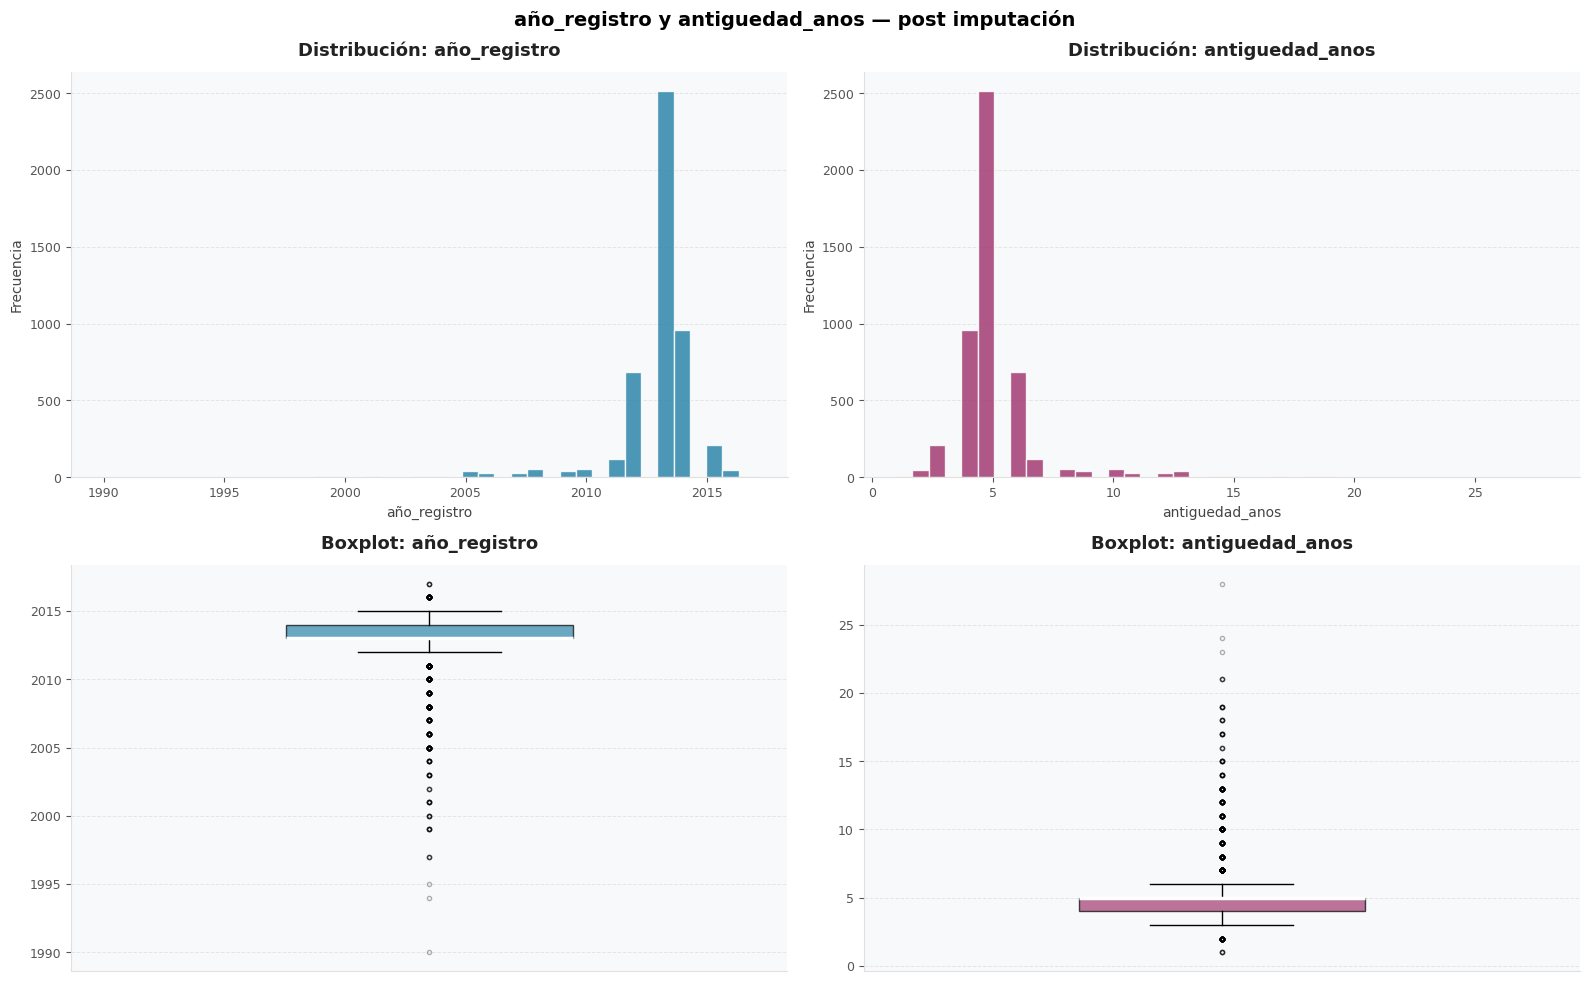

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('white')

for i, col in enumerate(['año_registro', 'antiguedad_anos']):
    data = df[col].dropna().astype(float)

    # Histograma
    axes[0, i].hist(data, bins=40, color=PALETTE[i], edgecolor='white', alpha=0.85)
    apply_style(axes[0, i], title=f'Distribución: {col}',
                xlabel=col, ylabel='Frecuencia')

    # Boxplot
    bp = axes[1, i].boxplot(data, vert=True, patch_artist=True, widths=0.4,
                             boxprops=dict(facecolor=PALETTE[i], alpha=0.7),
                             medianprops=dict(color='white', linewidth=2.5),
                             flierprops=dict(marker='o', markersize=3, alpha=0.3))
    apply_style(axes[1, i], title=f'Boxplot: {col}')
    axes[1, i].set_xticks([])

    print(f"{col}: media={data.mean():.1f}, mediana={data.median():.1f}, "
          f"std={data.std():.1f}, min={data.min():.0f}, max={data.max():.0f}")

plt.suptitle('año_registro y antiguedad_anos — post imputación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univ_anio_antiguedad.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.6 `asientos_traseros_plegables` — 3.391 nulos (70.0%)

#### Justificación: Alta tasa de missing — ¿vale la pena conservarla?

In [ ]:
# Distribución actual (antes de imputar)
vc_asientos = df['asientos_traseros_plegables'].value_counts(dropna=False).reset_index()
vc_asientos.columns = ['valor', 'n']
vc_asientos['%'] = (vc_asientos['n']/len(df)*100).round(1)
display(pretty_table(vc_asientos, precision=1))

# ¿El valor True cambia el precio significativamente? → justifica conservarla
g0 = df[df['asientos_traseros_plegables']==0]['precio'].dropna()
g1 = df[df['asientos_traseros_plegables']==1]['precio'].dropna()
if len(g0)>1 and len(g1)>1:
    f_as, p_as = stats.f_oneway(g0, g1)
    print(f"\nANOVA asientos_traseros_plegables → precio: F={f_as:.1f}, p={p_as:.4f}")
    print(f"Precio medio sin asientos plegables: €{g0.mean():,.0f}")
    print(f"Precio medio con asientos plegables: €{g1.mean():,.0f}")
    print(f"Diferencia: €{g1.mean()-g0.mean():,.0f}")
    print("\n→ A pesar del 70% de missing, la variable es predictiva → se imputa en lugar de eliminar.")


,valor,n,%
0,,"3,388",70.0
1,0,"1,147",23.7
2,1,302,6.2



ANOVA asientos_traseros_plegables → precio: F=338.0, p=0.0000
Precio medio sin asientos plegables: €13,903
Precio medio con asientos plegables: €23,539
Diferencia: €9,636

→ A pesar del 70% de missing, la variable es predictiva → se imputa en lugar de eliminar.


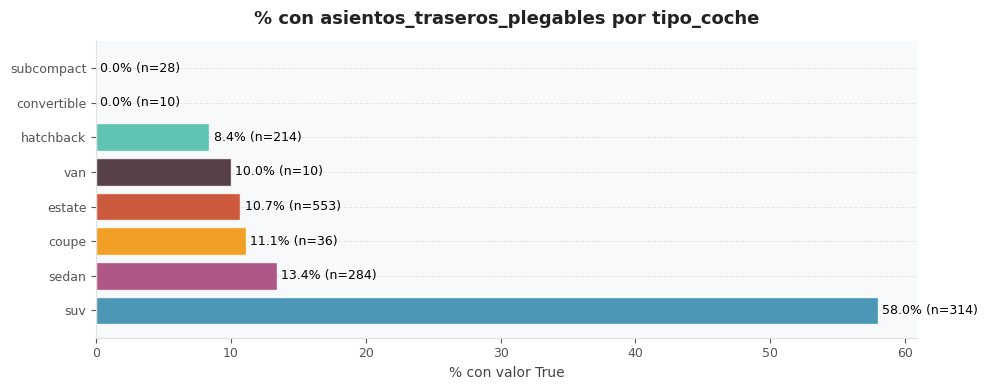

→ estate y van tienen alta tasa de asientos plegables (lógico por diseño).
→ Imputar por moda de tipo_coche captura este patrón estructural.


In [ ]:
# ¿Qué tipo_coche tiene más asientos traseros plegables?
tasa_asientos = (df.dropna(subset=['asientos_traseros_plegables','tipo_coche'])
                   .groupby('tipo_coche', observed=True)['asientos_traseros_plegables']
                   .agg(n='count', pct='mean').reset_index())
tasa_asientos['pct'] = (tasa_asientos['pct']*100).round(1)
tasa_asientos = tasa_asientos.sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('white')
colors_bar = [PALETTE[i%len(PALETTE)] for i in range(len(tasa_asientos))]
ax.barh(tasa_asientos['tipo_coche'], tasa_asientos['pct'], color=colors_bar, edgecolor='white', alpha=0.85)
for j, (_, row) in enumerate(tasa_asientos.iterrows()):
    ax.text(row['pct']+0.3, j, f"{row['pct']:.1f}% (n={row['n']})", va='center', fontsize=9)
apply_style(ax, title='% con asientos_traseros_plegables por tipo_coche',
            xlabel='% con valor True')
plt.tight_layout()
plt.savefig('just_asientos.png', dpi=130, bbox_inches='tight')
plt.show()
print("→ estate y van tienen alta tasa de asientos plegables (lógico por diseño).")
print("→ Imputar por moda de tipo_coche captura este patrón estructural.")


#### Imputación

In [ ]:
print(f"Nulos antes: {df['asientos_traseros_plegables'].isnull().sum():,} ({df['asientos_traseros_plegables'].isnull().mean()*100:.0f}%)")
df = completar_por_similitud(df, 'asientos_traseros_plegables', ['tipo_coche'])
print(f"Nulos después: {df['asientos_traseros_plegables'].isnull().sum()}")


Nulos antes: 3,388 (70%)
  🔧 asientos_traseros_plegables: 3,388 nulos imputados usando ['tipo_coche']
Nulos después: 0


### 7.7 Variables con ≤ 5 nulos — drop de filas

In [ ]:
few_null = [c for c in df.columns if 0 < df[c].isnull().sum() <= 5]
print(f"Variables con ≤5 nulos (drop de filas): {few_null}")
df = df.dropna(subset=few_null)
print(f"Shape tras dropna: {df.shape}")


Variables con ≤5 nulos (drop de filas): ['modelo', 'km', 'potencia', 'tipo_gasolina', 'volante_regulable', 'camara_trasera', 'elevalunas_electrico']
Shape tras dropna: (4817, 17)


### 7.8 Verificación final + Univariado de variables numéricas

In [ ]:
verificacion = pd.DataFrame({
    'métrica': ['Nulos totales', 'Filas', 'Columnas'],
    'valor':   [df.isnull().sum().sum(), df.shape[0], df.shape[1]]
})
display(pretty_table(verificacion, precision=0))
assert df.isnull().sum().sum() == 0, "❌ Quedan nulos"
print("\n✅ Dataset completamente imputado — sin nulos.")


,métrica,valor
0,Nulos totales,0
1,Filas,"4,817"
2,Columnas,17



✅ Dataset completamente imputado — sin nulos.


#### Análisis univariado: `km` y `potencia`

km: media=140991, mediana=141063, std=60237, outliers IQR=97 (2.0%)
potencia: media=129, mediana=120, std=39, outliers IQR=587 (12.2%)


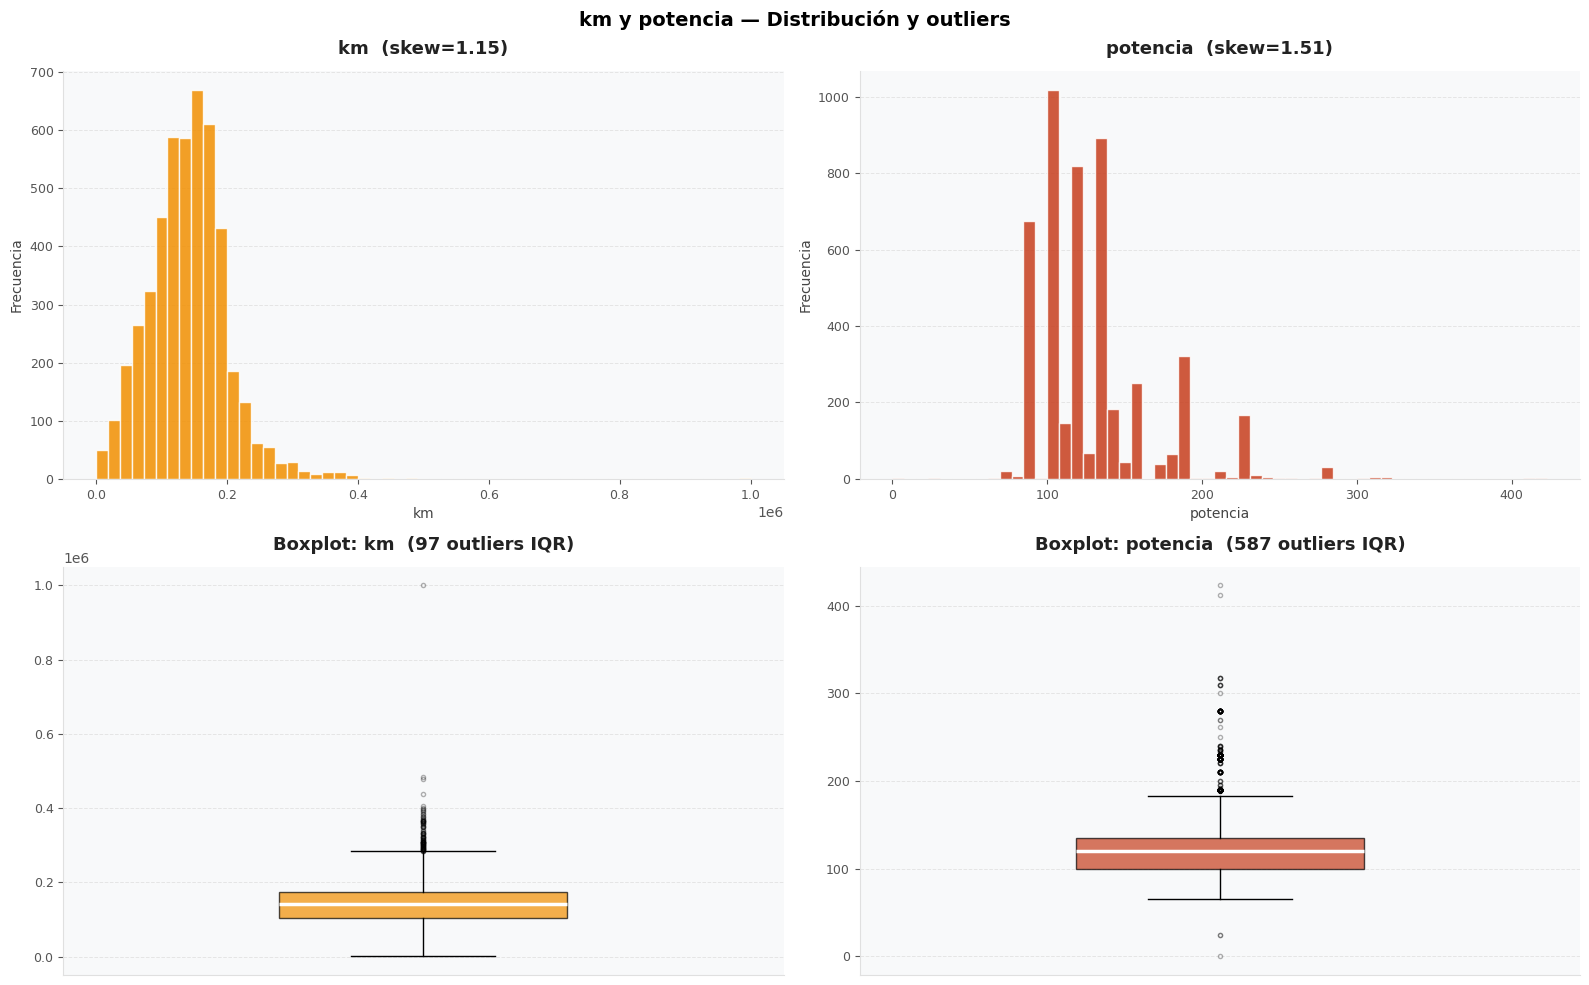

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('white')

for i, col in enumerate(['km', 'potencia']):
    data = df[col].dropna().astype(float)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1-1.5*iqr) | (data > q3+1.5*iqr)).sum()

    axes[0, i].hist(data, bins=55, color=PALETTE[i+2], edgecolor='white', alpha=0.85)
    apply_style(axes[0, i], title=f'{col}  (skew={data.skew():.2f})',
                xlabel=col, ylabel='Frecuencia')

    bp = axes[1, i].boxplot(data, vert=True, patch_artist=True, widths=0.4,
                             boxprops=dict(facecolor=PALETTE[i+2], alpha=0.7),
                             medianprops=dict(color='white', linewidth=2.5),
                             flierprops=dict(marker='o', markersize=3, alpha=0.3))
    apply_style(axes[1, i], title=f'Boxplot: {col}  ({n_out} outliers IQR)')
    axes[1, i].set_xticks([])

    print(f"{col}: media={data.mean():.0f}, mediana={data.median():.0f}, "
          f"std={data.std():.0f}, outliers IQR={n_out} ({n_out/len(data)*100:.1f}%)")

plt.suptitle('km y potencia — Distribución y outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univ_km_potencia.png', dpi=130, bbox_inches='tight')
plt.show()


#### Análisis univariado: variables binarias de equipamiento

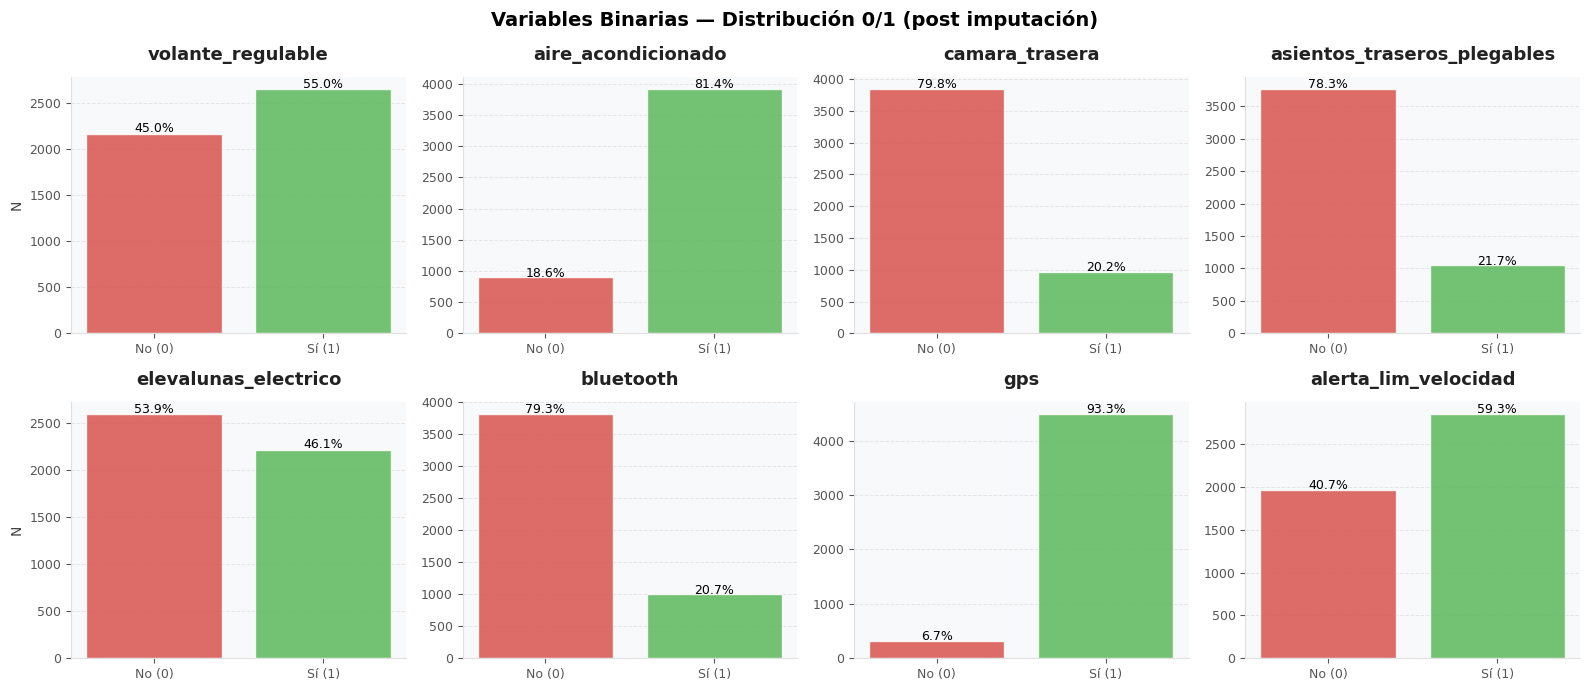

,variable,% con Sí (1),N
0,volante_regulable,55.0,"4,817"
1,aire_acondicionado,81.4,"4,817"
2,camara_trasera,20.2,"4,817"
3,asientos_traseros_plegables,21.7,"4,817"
4,elevalunas_electrico,46.1,"4,817"
5,bluetooth,20.7,"4,817"
6,gps,93.3,"4,817"
7,alerta_lim_velocidad,59.3,"4,817"


In [ ]:
bin_vars = ['volante_regulable', 'aire_acondicionado', 'camara_trasera',
            'asientos_traseros_plegables', 'elevalunas_electrico',
            'bluetooth', 'gps', 'alerta_lim_velocidad']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.patch.set_facecolor('white')
axes = axes.flatten()

tasa_bin = []
for i, col in enumerate(bin_vars):
    data = df[col].dropna().astype(int)
    vc   = data.value_counts().sort_index()
    pcts = data.value_counts(normalize=True).sort_index() * 100
    bars = axes[i].bar(['No (0)', 'Sí (1)'],
                        [vc.get(0,0), vc.get(1,0)],
                        color=['#d9534f','#5cb85c'], edgecolor='white', alpha=0.85)
    for bar, pct in zip(bars, [pcts.get(0,0), pcts.get(1,0)]):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+len(df)*0.003,
                     f'{pct:.1f}%', ha='center', fontsize=9)
    apply_style(axes[i], title=col, ylabel='N' if i%4==0 else '')
    tasa_bin.append({'variable': col, '% con Sí (1)': round(pcts.get(1,0),1), 'N': len(data)})

plt.suptitle('Variables Binarias — Distribución 0/1 (post imputación)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univ_binarias.png', dpi=130, bbox_inches='tight')
plt.show()
display(pretty_table(pd.DataFrame(tasa_bin), precision=1))


#### Análisis univariado: `precio` (target)

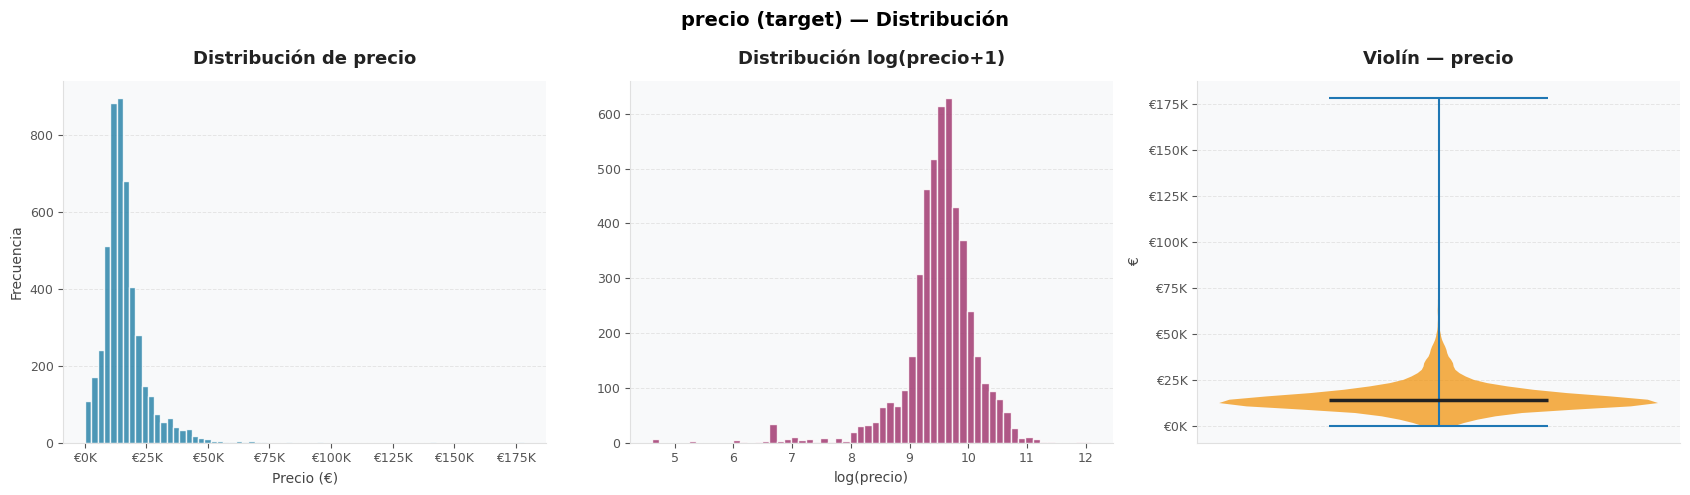

,estadístico,valor
0,count,"4,817.00"
1,mean,"15,827.13"
2,std,"9,185.11"
3,min,100.00
4,25%,"10,800.00"
5,50%,"14,200.00"
6,75%,"18,600.00"
7,max,"178,500.00"
8,skewness,3.33
9,kurtosis,33.16



→ Skewness = 3.32 → usar log(precio) como target en modelos lineales.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor('white')

axes[0].hist(df['precio'], bins=70, color=ACCENT, edgecolor='white', alpha=0.85)
apply_style(axes[0], title='Distribución de precio', xlabel='Precio (€)', ylabel='Frecuencia')
axes[0].xaxis.set_major_formatter(fmt_k)

axes[1].hist(np.log1p(df['precio']), bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85)
apply_style(axes[1], title='Distribución log(precio+1)', xlabel='log(precio)')

parts = axes[2].violinplot(df['precio'].dropna(), vert=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor(PALETTE[2]); pc.set_alpha(0.7)
parts['cmedians'].set_color('#222'); parts['cmedians'].set_linewidth(2.5)
apply_style(axes[2], title='Violín — precio', ylabel='€')
axes[2].yaxis.set_major_formatter(fmt_k)
axes[2].set_xticks([])

plt.suptitle('precio (target) — Distribución', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univ_precio.png', dpi=130, bbox_inches='tight')
plt.show()

desc = df['precio'].describe().rename('valor').reset_index().rename(columns={'index':'estadístico'})
extra = pd.DataFrame({'estadístico':['skewness','kurtosis'],
                       'valor':[df['precio'].skew(), df['precio'].kurtosis()]})
display(pretty_table(pd.concat([desc, extra], ignore_index=True), precision=2))
print("\n→ Skewness = 3.32 → usar log(precio) como target en modelos lineales.")


## 8. Feature Engineering

Antes del análisis exploratorio se crean nuevas variables derivadas que pueden aportar poder predictivo adicional. Estas features capturan relaciones que las variables originales no representan directamente.

| Feature | Tipo | Descripción | Correlación esperada |
|---|---|---|---|
| `serie` | Categórica | Gama del vehículo extraída del modelo (Serie 1, 3, 5, X, M…) | Alta (ANOVA) |
| `score_equipamiento` | Numérica 0–7 | Suma de las 7 booleanas de equipamiento | +0.436 |
| `km_por_año` | Numérica | Ritmo de uso anual del vehículo (km / antigüedad) | −0.067 |
| `potencia_vs_serie` | Z-score | Potencia relativa a la media de su gama | — |
| `log_precio` | Target transformado | Corrige el sesgo (skew 3.32) para modelos lineales | — |


### 8.1 `serie` — Gama del vehículo

In [ ]:
# Extraemos la gama a partir del nombre del modelo:
# - Prefijos literales primero: X, M, i, Z
# - Para el resto: primer dígito del modelo (1→Serie 1, 3→Serie 3, etc.)
def get_serie(m):
    if pd.isna(m): return np.nan
    m = str(m).strip()
    for prefix in ['X', 'M', 'i', 'Z']:
        if m.startswith(prefix): return prefix
    d = ''.join(c for c in m if c.isdigit())
    return d[0] + '_series' if d else 'other'

df['serie'] = df['modelo'].apply(get_serie)

# Distribución y precio medio por serie
dist_serie = (df.groupby('serie', observed=True)['precio']
                .agg(n='count', precio_medio='mean', precio_mediano='median')
                .sort_values('precio_medio', ascending=False)
                .reset_index())
dist_serie['precio_medio']   = dist_serie['precio_medio'].round(0).astype(int)
dist_serie['precio_mediano'] = dist_serie['precio_mediano'].round(0).astype(int)
dist_serie['% del total']    = (dist_serie['n'] / len(df) * 100).round(1)

display(pretty_table(dist_serie, precision=0))


,serie,n,precio_medio,precio_mediano,% del total
0,M,26,"36,627","36,800",0
1,6_series,29,"32,817","33,100",1
2,i,7,"31,700","20,900",0
3,7_series,54,"28,576","25,350",1
4,4_series,101,"25,185","25,000",2
5,X,"1,060","21,468","17,700",22
6,other,1,"19,000","19,000",0
7,5_series,"1,135","16,766","16,700",24
8,2_series,49,"16,727","16,200",1
9,3_series,"1,786","12,164","12,400",37


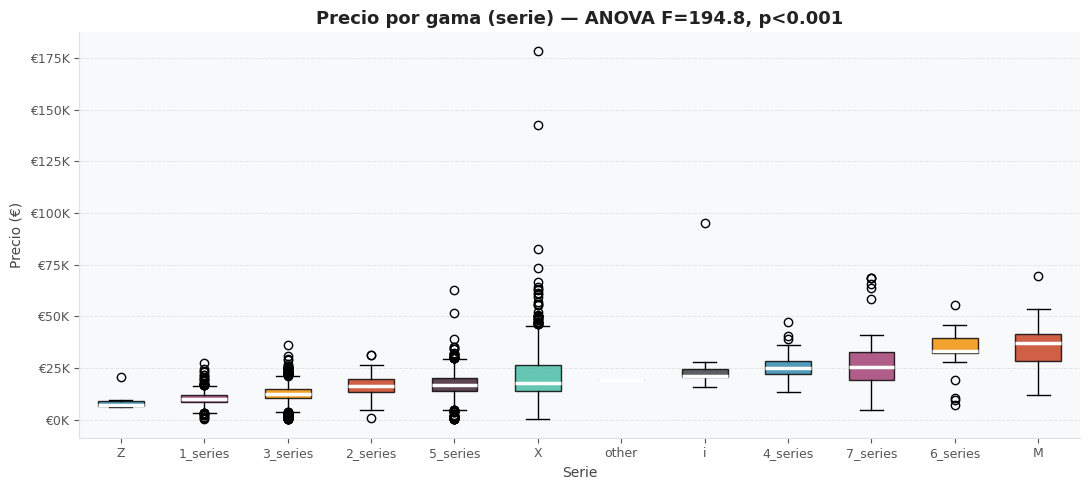

ANOVA serie → precio: F=194.79, p=0.00e+00 ✅ Significativo


In [ ]:
# Visualización: precio por serie
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')

orden = df.groupby('serie', observed=True)['precio'].median().sort_values().index
data_bp = [df[df['serie']==s]['precio'].dropna().values for s in orden]

bp = ax.boxplot(data_bp, labels=orden, patch_artist=True, widths=0.55,
                medianprops=dict(color='white', linewidth=2.5))
for j, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE[j % len(PALETTE)])
    patch.set_alpha(0.82)

apply_style(ax, title='Precio por gama (serie)', xlabel='Serie', ylabel='Precio (€)')
ax.yaxis.set_major_formatter(fmt_k)

# ANOVA
grupos = [g for g in data_bp if len(g) > 1]
f_stat, p_val = stats.f_oneway(*grupos)
ax.set_title(f'Precio por gama (serie) — ANOVA F={f_stat:.1f}, p<0.001', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fe_serie_precio.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"ANOVA serie → precio: F={f_stat:.2f}, p={p_val:.2e} ✅ Significativo")


### 8.2 `score_equipamiento` — Índice de equipamiento (0–7)

Suma de las 7 variables booleanas de equipamiento. Captura de forma compacta cuán equipado está el vehículo.


In [ ]:
EQUIP_COLS = ['volante_regulable', 'aire_acondicionado', 'camara_trasera',
              'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad']

df['score_equipamiento'] = df[EQUIP_COLS].astype(float).sum(axis=1).astype(int)

# Distribución y precio medio
dist_score = (df.groupby('score_equipamiento')['precio']
                .agg(n='count', precio_medio='mean', precio_mediano='median')
                .reset_index())
dist_score['precio_medio']   = dist_score['precio_medio'].round(0).astype(int)
dist_score['precio_mediano'] = dist_score['precio_mediano'].round(0).astype(int)
dist_score['% del total']    = (dist_score['n'] / len(df) * 100).round(1)

corr_score = df[['score_equipamiento','precio']].corr().iloc[0,1]
print(f"Correlación score_equipamiento con precio: {corr_score:.3f}")
display(pretty_table(dist_score, precision=0))


Correlación score_equipamiento con precio: 0.443


,score_equipamiento,n,precio_medio,precio_mediano,% del total
0,0,62,"11,235","12,050",1
1,1,405,"11,545","10,600",8
2,2,683,"10,672","10,600",14
3,3,974,"12,501","12,200",20
4,4,973,"15,636","14,400",20
5,5,954,"19,700","17,300",20
6,6,611,"22,576","20,000",13
7,7,155,"23,230","21,500",3


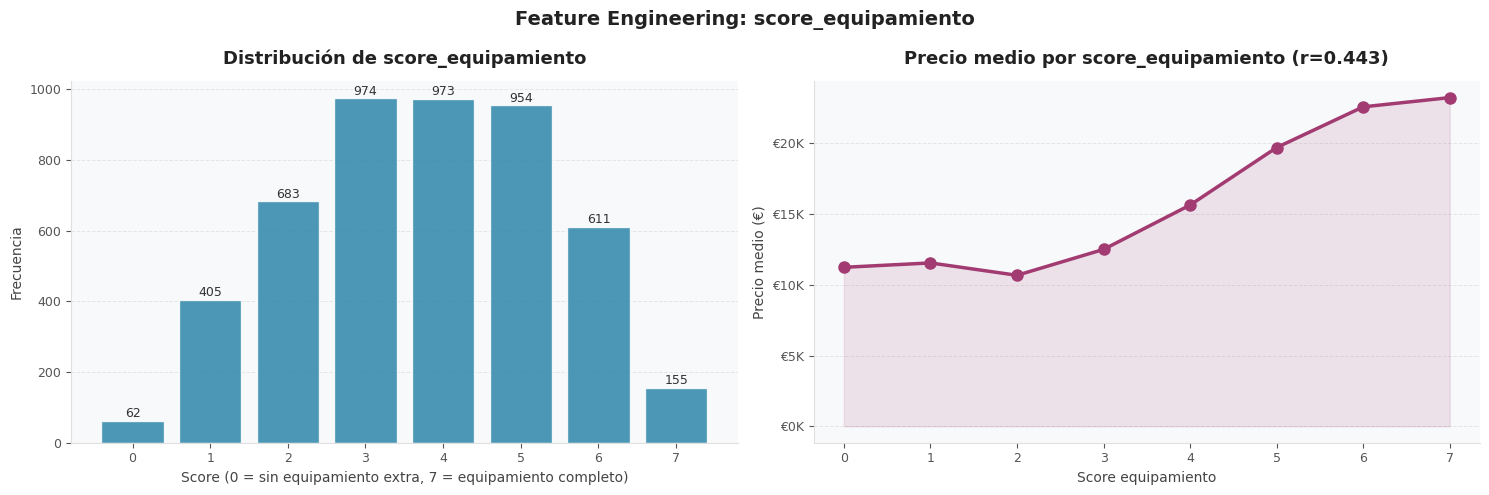

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('white')

# Barplot: distribución de scores
vc = df['score_equipamiento'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=PALETTE[0], alpha=0.85, edgecolor='white')
for x, v in zip(vc.index, vc.values):
    axes[0].text(x, v + 10, f'{v:,}', ha='center', fontsize=9, color='#333')
apply_style(axes[0], title='Distribución de score_equipamiento',
            xlabel='Score (0 = sin equipamiento extra, 7 = equipamiento completo)',
            ylabel='Frecuencia')

# Precio medio por score — línea + puntos
precio_by_score = df.groupby('score_equipamiento')['precio'].mean()
axes[1].plot(precio_by_score.index, precio_by_score.values,
             color=PALETTE[1], marker='o', linewidth=2.5, markersize=8)
axes[1].fill_between(precio_by_score.index, precio_by_score.values,
                      alpha=0.12, color=PALETTE[1])
apply_style(axes[1], title=f'Precio medio por score_equipamiento (r={corr_score:.3f})',
            xlabel='Score equipamiento', ylabel='Precio medio (€)')
axes[1].yaxis.set_major_formatter(fmt_k)

plt.suptitle('Feature Engineering: score_equipamiento', fontsize=14, fontweight='bold', color='#222')
plt.tight_layout()
plt.savefig('fe_score_equipamiento.png', dpi=130, bbox_inches='tight')
plt.show()


### 8.3 `km_por_año` — Ritmo de uso anual

Mide la intensidad de uso del vehículo: `km / antigüedad_anos`. Un coche con 150.000 km y 10 años de antigüedad usa 15.000 km/año (uso normal); el mismo kilometraje en 3 años indica uso intensivo.

- Se usa `replace(0, NaN)` para evitar divisiones por cero (coches nuevos).  
- Se winsoriza al percentil 99 para controlar outliers extremos.  
- Los nulos resultantes se imputan con la mediana.


In [ ]:
df['km_por_año'] = (
    df['km'] / df['antiguedad_anos'].replace(0, np.nan)
).round(0)

# Winsorizar al p99
p99_kpa = df['km_por_año'].quantile(0.99)
df['km_por_año'] = df['km_por_año'].clip(upper=p99_kpa)

# Imputar nulos con mediana
mediana_kpa = df['km_por_año'].median()
df['km_por_año'] = df['km_por_año'].fillna(mediana_kpa)

corr_kpa = df[['km_por_año','precio']].corr().iloc[0,1]

desc_kpa = df['km_por_año'].describe().rename('valor').reset_index().rename(columns={'index':'estadístico'})
desc_kpa['valor'] = desc_kpa['valor'].round(1)
display(pretty_table(desc_kpa, precision=1))
print(f"\nCorrelación km_por_año con precio: {corr_kpa:.3f}")
print(f"Límite winsorización (p99): {p99_kpa:,.0f} km/año")


,estadístico,valor
0,count,"4,817.0"
1,mean,"27,736.8"
2,std,"11,335.1"
3,min,119.0
4,25%,"19,883.0"
5,50%,"27,100.0"
6,75%,"34,803.0"
7,max,"61,970.8"



Correlación km_por_año con precio: -0.197
Límite winsorización (p99): 61,971 km/año


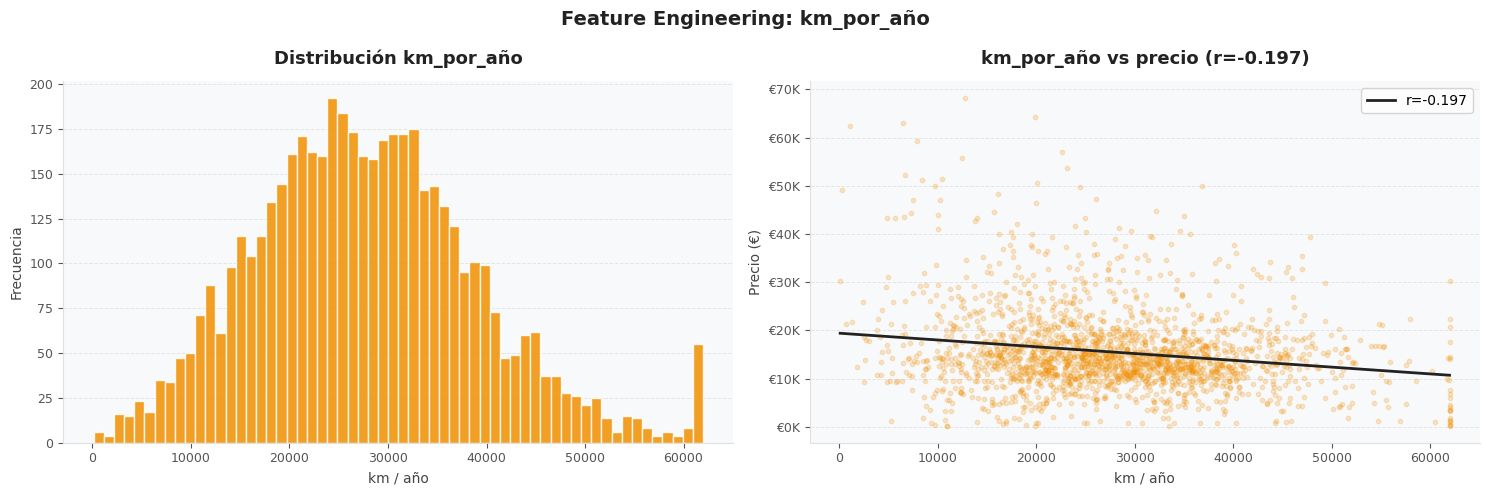

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('white')

# Histograma
axes[0].hist(df['km_por_año'], bins=60, color=PALETTE[2], edgecolor='white', alpha=0.85)
apply_style(axes[0], title='Distribución km_por_año', xlabel='km / año', ylabel='Frecuencia')

# Scatter vs precio
sample = df[['km_por_año','precio']].sample(min(2000, len(df)), random_state=42)
axes[1].scatter(sample['km_por_año'], sample['precio'], alpha=0.2, s=10, color=PALETTE[2])
z = np.polyfit(sample['km_por_año'], sample['precio'], 1)
xline = np.linspace(sample['km_por_año'].min(), sample['km_por_año'].max(), 200)
axes[1].plot(xline, np.poly1d(z)(xline), color='#222', linewidth=2, label=f'r={corr_kpa:.3f}')
apply_style(axes[1], title=f'km_por_año vs precio (r={corr_kpa:.3f})',
            xlabel='km / año', ylabel='Precio (€)')
axes[1].yaxis.set_major_formatter(fmt_k)
axes[1].legend(fontsize=10)

plt.suptitle('Feature Engineering: km_por_año', fontsize=14, fontweight='bold', color='#222')
plt.tight_layout()
plt.savefig('fe_km_por_año.png', dpi=130, bbox_inches='tight')
plt.show()


### 8.4 `potencia_vs_serie` — Potencia relativa dentro de la gama

Z-score de la potencia dentro de cada gama (serie). Un valor de +2 significa que el coche tiene 2 desviaciones estándar más potencia que el promedio de su gama — útil para detectar versiones deportivas dentro de cada serie sin mezclar Series 1 con Series 5.

- Series con una sola observación (std=0) → se imputa con 0 (potencia exactamente en la media de su gama).


In [ ]:
df['potencia_vs_serie'] = df.groupby('serie', observed=True)['potencia'].transform(
    lambda x: (x - x.mean()) / x.std()
)
# Series con 1 observación → std=0 → NaN → imputar con 0
df['potencia_vs_serie'] = df['potencia_vs_serie'].fillna(0)

corr_pvs = df[['potencia_vs_serie','precio']].corr().iloc[0,1]

desc_pvs = df['potencia_vs_serie'].describe().rename('valor').reset_index().rename(columns={'index':'estadístico'})
desc_pvs['valor'] = desc_pvs['valor'].round(3)
display(pretty_table(desc_pvs, precision=3))
print(f"\nCorrelación potencia_vs_serie con precio: {corr_pvs:.3f}")


,estadístico,valor
0,count,"4,817.000"
1,mean,0.000
2,std,0.999
3,min,-3.378
4,25%,-0.636
5,50%,-0.274
6,75%,0.536
7,max,7.258



Correlación potencia_vs_serie con precio: 0.372


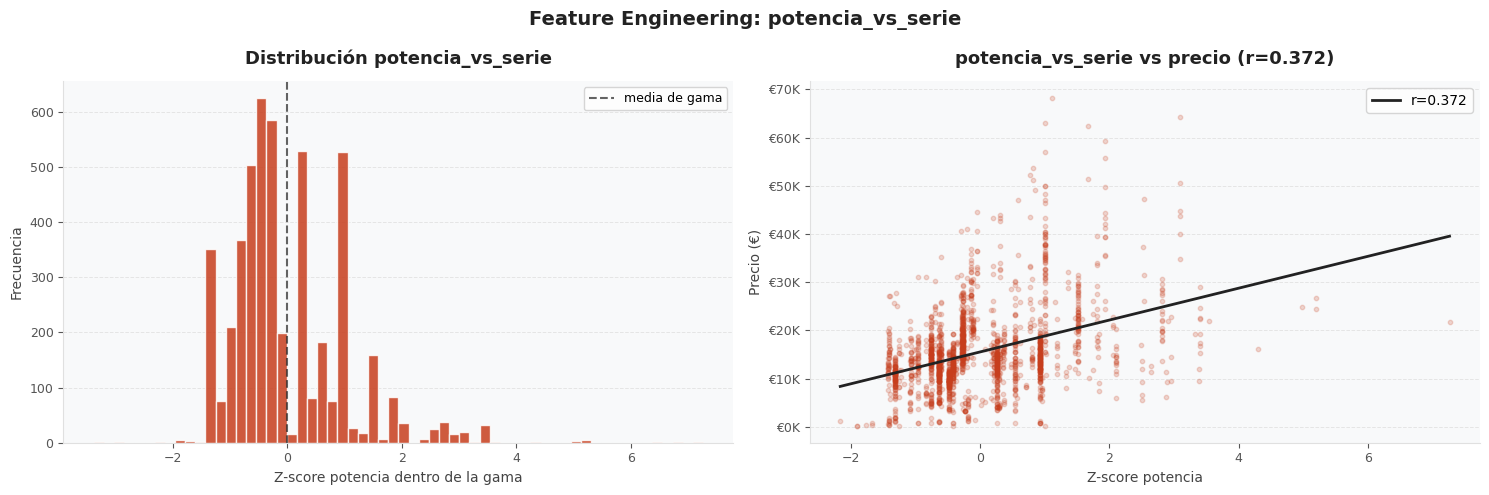

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('white')

# Histograma
axes[0].hist(df['potencia_vs_serie'], bins=60, color=PALETTE[3], edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='#222', linestyle='--', linewidth=1.5, alpha=0.7, label='media de gama')
apply_style(axes[0], title='Distribución potencia_vs_serie',
            xlabel='Z-score potencia dentro de la gama', ylabel='Frecuencia')
axes[0].legend(fontsize=9)

# Scatter vs precio
sample = df[['potencia_vs_serie','precio']].sample(min(2000, len(df)), random_state=42)
axes[1].scatter(sample['potencia_vs_serie'], sample['precio'], alpha=0.2, s=10, color=PALETTE[3])
z = np.polyfit(sample['potencia_vs_serie'], sample['precio'], 1)
xline = np.linspace(sample['potencia_vs_serie'].min(), sample['potencia_vs_serie'].max(), 200)
axes[1].plot(xline, np.poly1d(z)(xline), color='#222', linewidth=2, label=f'r={corr_pvs:.3f}')
apply_style(axes[1], title=f'potencia_vs_serie vs precio (r={corr_pvs:.3f})',
            xlabel='Z-score potencia', ylabel='Precio (€)')
axes[1].yaxis.set_major_formatter(fmt_k)
axes[1].legend(fontsize=10)

plt.suptitle('Feature Engineering: potencia_vs_serie', fontsize=14, fontweight='bold', color='#222')
plt.tight_layout()
plt.savefig('fe_potencia_vs_serie.png', dpi=130, bbox_inches='tight')
plt.show()


### 8.5 `log_precio` — Target transformado

Con skewness = 3.32, la distribución de precio viola los supuestos de los modelos lineales (residuos normales). La transformación logarítmica corrige este sesgo y hace que la relación con las features sea más lineal.


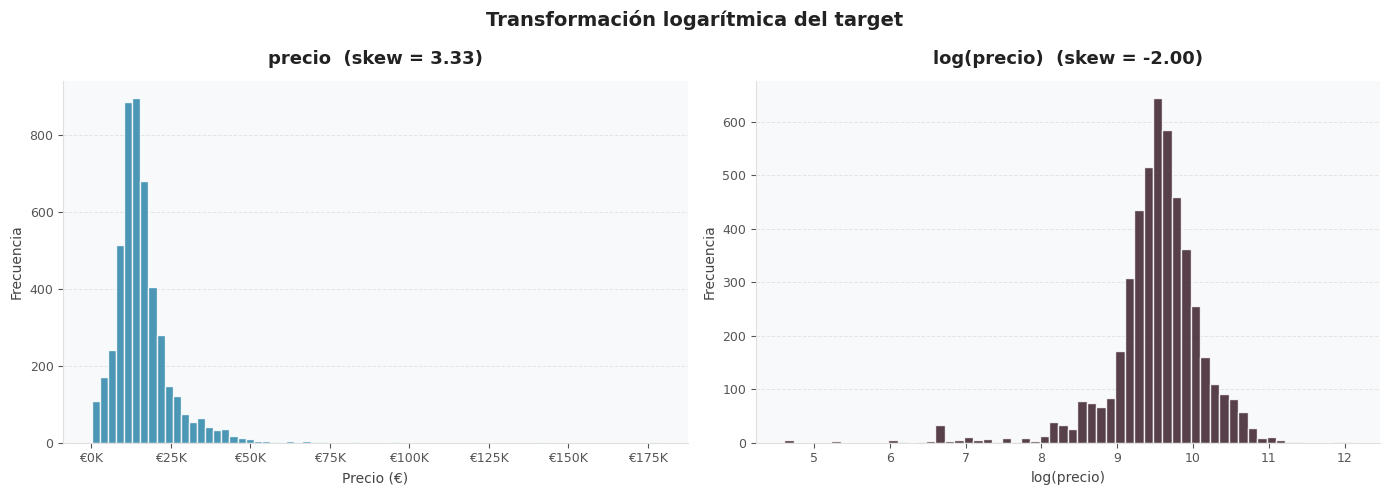

Skewness precio original:   3.326
Skewness log(precio):       -1.995  ✅ Mucho más simétrico


In [ ]:
df['log_precio'] = np.log(df['precio'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

axes[0].hist(df['precio'], bins=70, color=ACCENT, edgecolor='white', alpha=0.85)
apply_style(axes[0], title=f'precio  (skew = {df["precio"].skew():.2f})',
            xlabel='Precio (€)', ylabel='Frecuencia')
axes[0].xaxis.set_major_formatter(fmt_k)

axes[1].hist(df['log_precio'], bins=60, color=PALETTE[4], edgecolor='white', alpha=0.85)
apply_style(axes[1], title=f'log(precio)  (skew = {df["log_precio"].skew():.2f})',
            xlabel='log(precio)', ylabel='Frecuencia')

plt.suptitle('Transformación logarítmica del target', fontsize=14, fontweight='bold', color='#222')
plt.tight_layout()
plt.savefig('fe_log_precio.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Skewness precio original:   {df['precio'].skew():.3f}")
print(f"Skewness log(precio):       {df['log_precio'].skew():.3f}  ✅ Mucho más simétrico")


### 8.6 Resumen: correlación de todas las features con precio

In [ ]:
# Correlación de features engineered + originales con precio
fe_num_cols = ['km', 'potencia', 'antiguedad_anos', 'km_por_año',
               'score_equipamiento', 'potencia_vs_serie']

corrs_fe = []
for col in fe_num_cols:
    d = df[[col,'precio']].dropna().astype(float)
    r, p = stats.pearsonr(d[col], d['precio'])
    rl, _ = stats.pearsonr(d[col], np.log1p(d['precio']))
    origen = ('🔧 Engineered' if col in ['km_por_año','score_equipamiento','potencia_vs_serie']
              else '📦 Original')
    corrs_fe.append({'variable': col, 'origen': origen,
                     'r con precio': round(r, 4),
                     'r con log(precio)': round(rl, 4),
                     'mejor target': 'log(precio)' if abs(rl) > abs(r) else 'precio'})

display(pretty_table(pd.DataFrame(corrs_fe), precision=4))


,variable,origen,r con precio,r con log(precio),mejor target
0,km,📦 Original,-0.4089,-0.4374,log(precio)
1,potencia,📦 Original,0.6386,0.5067,precio
2,antiguedad_anos,📦 Original,-0.3574,-0.4781,log(precio)
3,km_por_año,🔧 Engineered,-0.1968,-0.1612,precio
4,score_equipamiento,🔧 Engineered,0.4429,0.4641,log(precio)
5,potencia_vs_serie,🔧 Engineered,0.3721,0.3143,precio


## 10. Análisis de Correlación Inicial

### 10.1 Pearson — Variables Numéricas

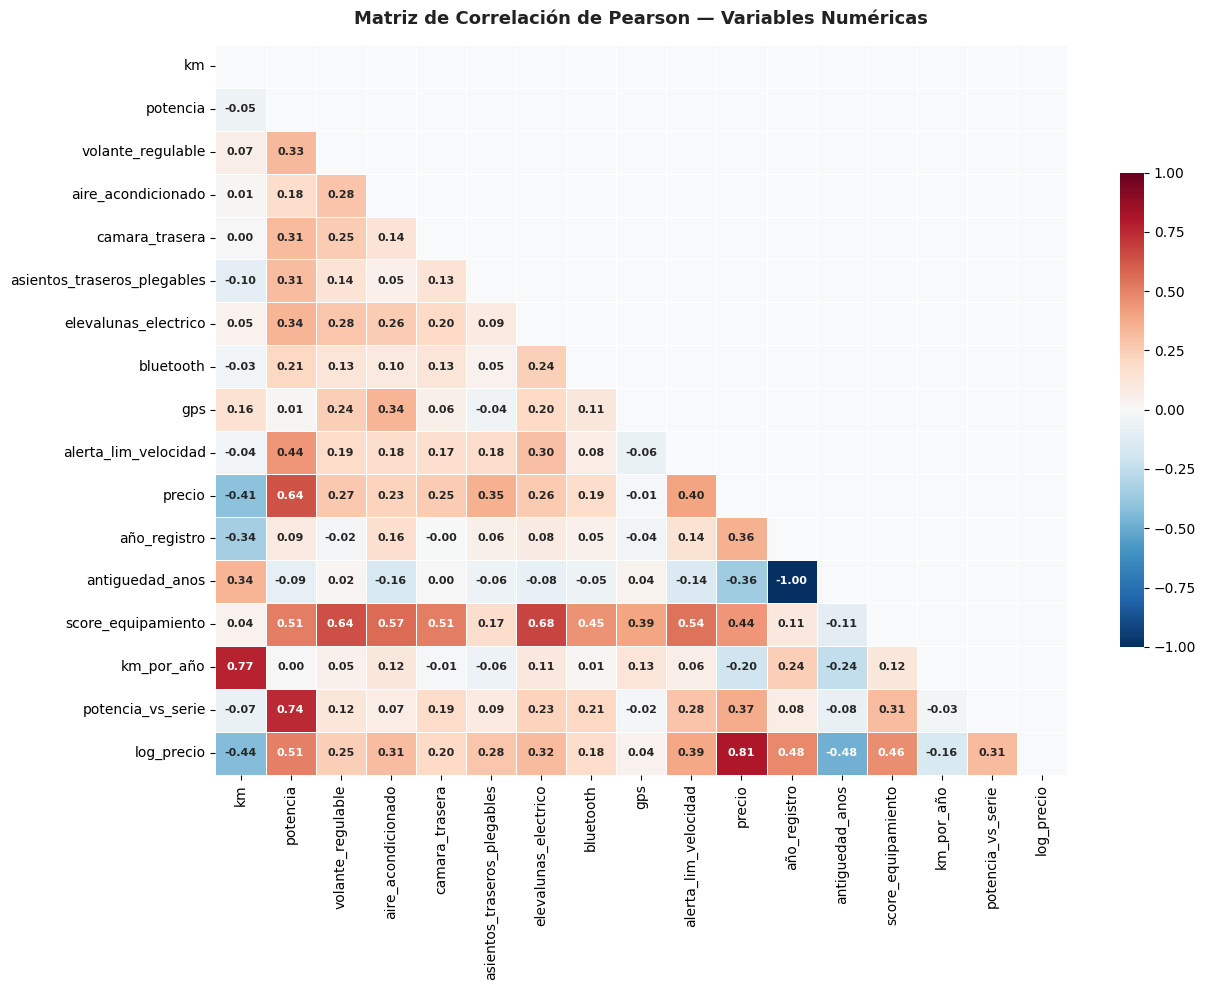

In [ ]:
num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
df_corr   = df[num_cols].astype(float)
corr_m    = df_corr.corr()

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('white')
mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8, 'weight': 'bold'},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.65})
ax.set_facecolor(BG)
ax.set_title('Matriz de Correlación de Pearson — Variables Numéricas',
             fontsize=13, fontweight='bold', pad=15, color='#222')
plt.tight_layout()
plt.savefig('correlacion_pearson.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
corr_precio = (corr_m['precio'].drop('precio')
                .reset_index()
                .rename(columns={'index':'variable', 'precio':'correlacion_r'}))
corr_precio['|r|'] = corr_precio['correlacion_r'].abs().round(4)
corr_precio['signo'] = corr_precio['correlacion_r'].apply(lambda x: '↑ positiva' if x>0 else '↓ negativa')
corr_precio = corr_precio.sort_values('|r|', ascending=False).reset_index(drop=True)

display(pretty_table(corr_precio[['variable','correlacion_r','|r|','signo']], precision=4))


,variable,correlacion_r,|r|,signo
0,log_precio,0.8089,0.8089,↑ positiva
1,potencia,0.6386,0.6386,↑ positiva
2,score_equipamiento,0.4429,0.4429,↑ positiva
3,km,-0.4089,0.4089,↓ negativa
4,alerta_lim_velocidad,0.3986,0.3986,↑ positiva
5,potencia_vs_serie,0.3721,0.3721,↑ positiva
6,año_registro,0.3574,0.3574,↑ positiva
7,antiguedad_anos,-0.3574,0.3574,↓ negativa
8,asientos_traseros_plegables,0.3542,0.3542,↑ positiva
9,volante_regulable,0.2675,0.2675,↑ positiva


### 10.2 V de Cramér — Variables Categóricas

In [ ]:
cat_cramers = ['tipo_coche', 'tipo_gasolina', 'color', 'modelo']
cm_rows = []
for c1 in cat_cramers:
    for c2 in cat_cramers:
        if c1 < c2:
            v = cramers_v(df[c1].fillna('?'), df[c2].fillna('?'))
            nivel = ("🔴 Muy alta" if v > 0.7 else "🟠 Alta" if v > 0.5
                     else "🟡 Moderada" if v > 0.3 else "🟢 Baja")
            cm_rows.append({'variable A': c1, 'variable B': c2,
                            'V de Cramér': round(v, 3), 'nivel': nivel})

display(pretty_table(pd.DataFrame(cm_rows), precision=3))


,variable A,variable B,V de Cramér,nivel
0,tipo_coche,tipo_gasolina,0.149,🟢 Baja
1,color,tipo_coche,0.088,🟢 Baja
2,color,tipo_gasolina,0.036,🟢 Baja
3,color,modelo,0.142,🟢 Baja
4,modelo,tipo_coche,0.754,🔴 Muy alta
5,modelo,tipo_gasolina,0.622,🟠 Alta


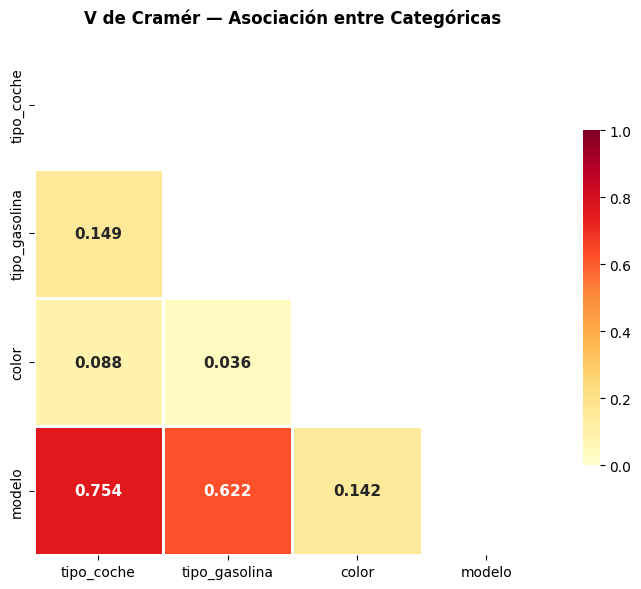

In [ ]:
# Heatmap Cramér
cm_matrix = pd.DataFrame(index=cat_cramers, columns=cat_cramers, dtype=float)
for c1 in cat_cramers:
    for c2 in cat_cramers:
        try:    cm_matrix.loc[c1,c2] = cramers_v(df[c1].fillna('?'), df[c2].fillna('?'))
        except: cm_matrix.loc[c1,c2] = 0.0
cm_matrix = cm_matrix.astype(float)

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')
mask = np.triu(np.ones_like(cm_matrix, dtype=bool))
sns.heatmap(cm_matrix, mask=mask, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, annot_kws={'size':11,'weight':'bold'},
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.65})
ax.set_title("V de Cramér — Asociación entre Categóricas",
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('cramers_v.png', dpi=130, bbox_inches='tight')
plt.show()


## 11. Análisis Bivariado — Variables vs Target (precio)

### 11.1 Variables Numéricas vs precio

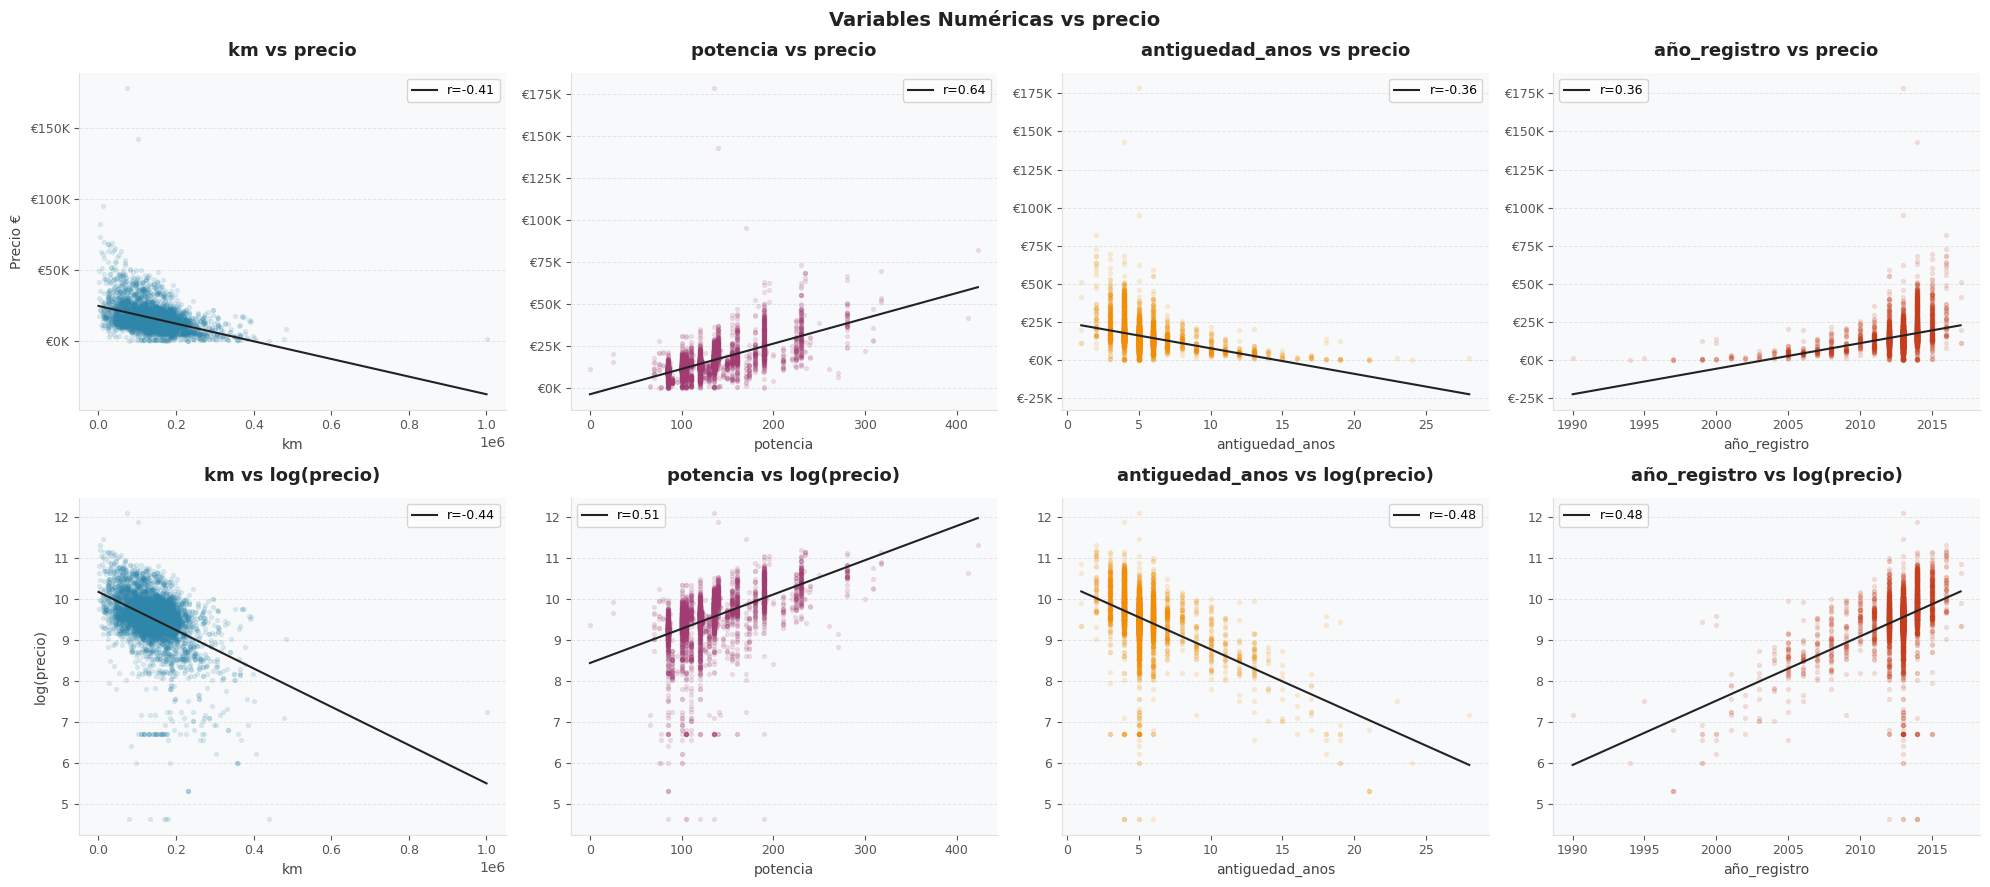

In [ ]:
num_vs_p = ['km', 'potencia', 'antiguedad_anos', 'año_registro']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('white')

for i, col in enumerate(num_vs_p):
    d      = df[[col,'precio']].dropna().astype(float)
    r, _   = stats.pearsonr(d[col], d['precio'])
    r_log,_= stats.pearsonr(d[col], np.log1p(d['precio']))

    # vs precio
    axes[0,i].scatter(d[col], d['precio'], alpha=0.12, s=8, color=PALETTE[i])
    xline = np.linspace(d[col].min(), d[col].max(), 200)
    axes[0,i].plot(xline, np.poly1d(np.polyfit(d[col], d['precio'], 1))(xline),
                   color='#222', linewidth=1.5, label=f'r={r:.2f}')
    apply_style(axes[0,i], title=f'{col} vs precio',
                xlabel=col, ylabel='Precio €' if i==0 else '')
    axes[0,i].yaxis.set_major_formatter(fmt_k)
    axes[0,i].legend(fontsize=9)

    # vs log(precio)
    axes[1,i].scatter(d[col], np.log1p(d['precio']), alpha=0.12, s=8, color=PALETTE[i])
    axes[1,i].plot(xline, np.poly1d(np.polyfit(d[col], np.log1p(d['precio']), 1))(xline),
                   color='#222', linewidth=1.5, label=f'r={r_log:.2f}')
    apply_style(axes[1,i], title=f'{col} vs log(precio)',
                xlabel=col, ylabel='log(precio)' if i==0 else '')
    axes[1,i].legend(fontsize=9)

plt.suptitle('Variables Numéricas vs precio', fontsize=14, fontweight='bold', color='#222')
plt.tight_layout()
plt.savefig('bivar_numericas.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
corr_bivar = []
for col in num_vs_p:
    d      = df[[col,'precio']].dropna().astype(float)
    r,_    = stats.pearsonr(d[col], d['precio'])
    rl,_   = stats.pearsonr(d[col], np.log1p(d['precio']))
    corr_bivar.append({'variable': col, 'r con precio': round(r,4),
                       'r con log(precio)': round(rl,4),
                       'mejor target': 'log(precio)' if abs(rl)>abs(r) else 'precio'})
display(pretty_table(pd.DataFrame(corr_bivar), precision=4))


,variable,r con precio,r con log(precio),mejor target
0,km,-0.4089,-0.4374,log(precio)
1,potencia,0.6386,0.5067,precio
2,antiguedad_anos,-0.3574,-0.4781,log(precio)
3,año_registro,0.3574,0.4781,log(precio)


### 11.2 Variables Categóricas vs precio

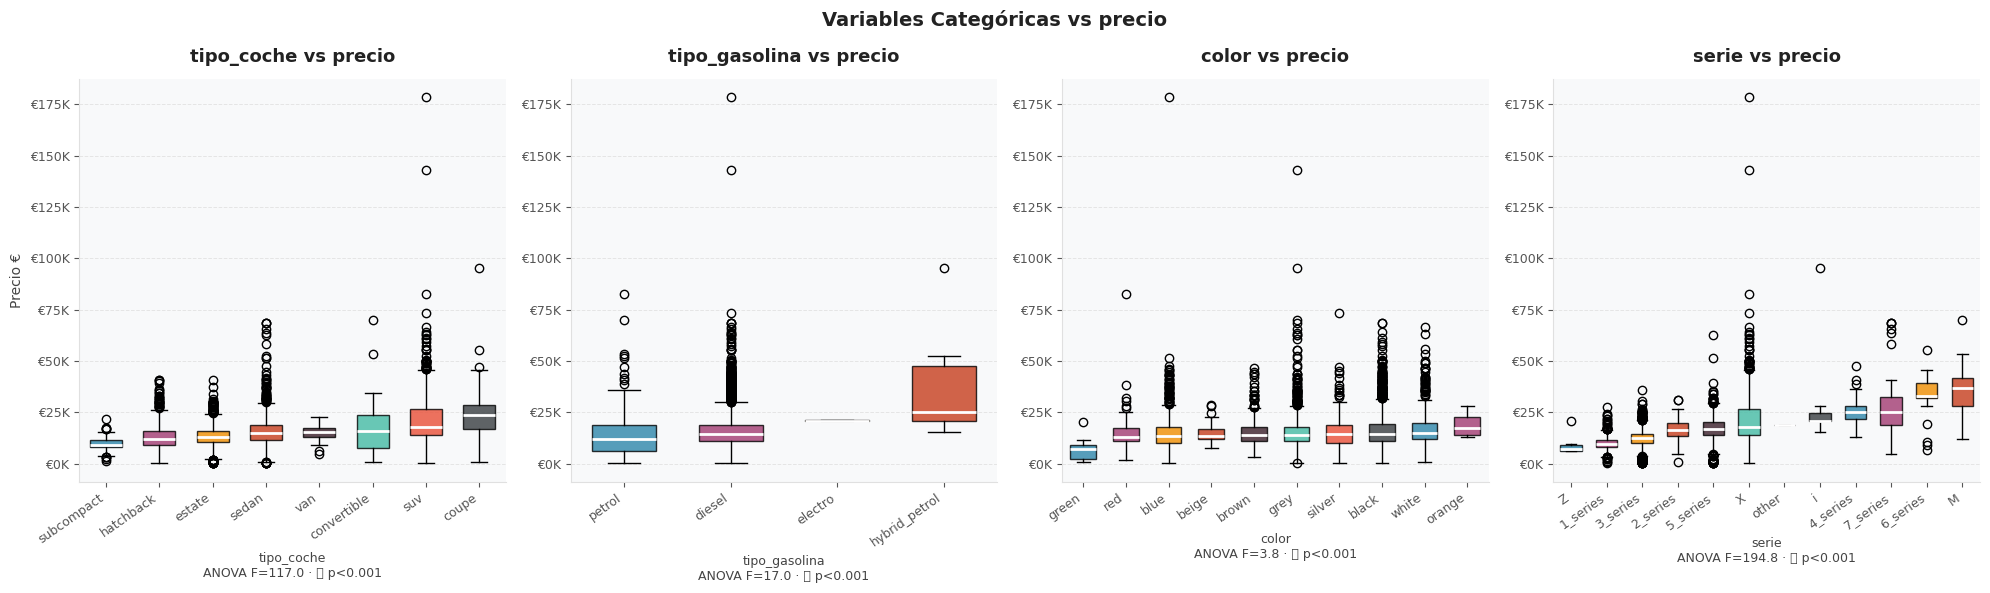

In [ ]:
cat_vs_p = ['tipo_coche', 'tipo_gasolina', 'color', 'serie']
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.patch.set_facecolor('white')

for i, col in enumerate(cat_vs_p):
    orden    = df.groupby(col, observed=True)['precio'].median().sort_values().index
    data_bp  = [df[df[col]==cat]['precio'].dropna().values for cat in orden]
    bp = axes[i].boxplot(data_bp, labels=orden, patch_artist=True, widths=0.6,
                         medianprops=dict(color='white', linewidth=2))
    for j, patch in enumerate(bp['boxes']):
        patch.set_facecolor(PALETTE[j % len(PALETTE)]); patch.set_alpha(0.8)
    apply_style(axes[i], title=f'{col} vs precio',
                xlabel=col, ylabel='Precio €' if i==0 else '', rotate_x=True)
    axes[i].yaxis.set_major_formatter(fmt_k)
    grupos = [g for g in data_bp if len(g) > 1]
    if len(grupos) >= 2:
        f, p = stats.f_oneway(*grupos)
        axes[i].set_xlabel(f'{col}\nANOVA F={f:.1f} · {"✅ p<0.001" if p<0.001 else f"p={p:.3f}"}', fontsize=9)

plt.suptitle('Variables Categóricas vs precio', fontsize=14, fontweight='bold', color='#222')
plt.tight_layout()
plt.savefig('bivar_categoricas.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
precio_por_cat = []
for col in cat_vs_p:
    for cat, g in df.groupby(col, observed=True):
        precio_por_cat.append({'variable': col, 'categoría': cat,
                               'precio medio': round(g['precio'].mean()),
                               'precio mediano': round(g['precio'].median()),
                               'N': len(g)})
display(pretty_table(pd.DataFrame(precio_por_cat), precision=0))


,variable,categoría,precio medio,precio mediano,N
0,tipo_coche,convertible,"17,213","15,800",39
1,tipo_coche,coupe,"23,619","23,800",94
2,tipo_coche,estate,"13,296","13,200","1,806"
3,tipo_coche,hatchback,"13,246","11,900",750
4,tipo_coche,sedan,"16,073","14,800",954
5,tipo_coche,subcompact,"9,732","9,300",77
6,tipo_coche,suv,"21,481","17,700","1,059"
7,tipo_coche,van,"15,018","15,250",38
8,tipo_gasolina,diesel,"15,845","14,300","4,615"
9,tipo_gasolina,electro,"20,967","20,900",3


### 11.3 Variables Binarias vs precio

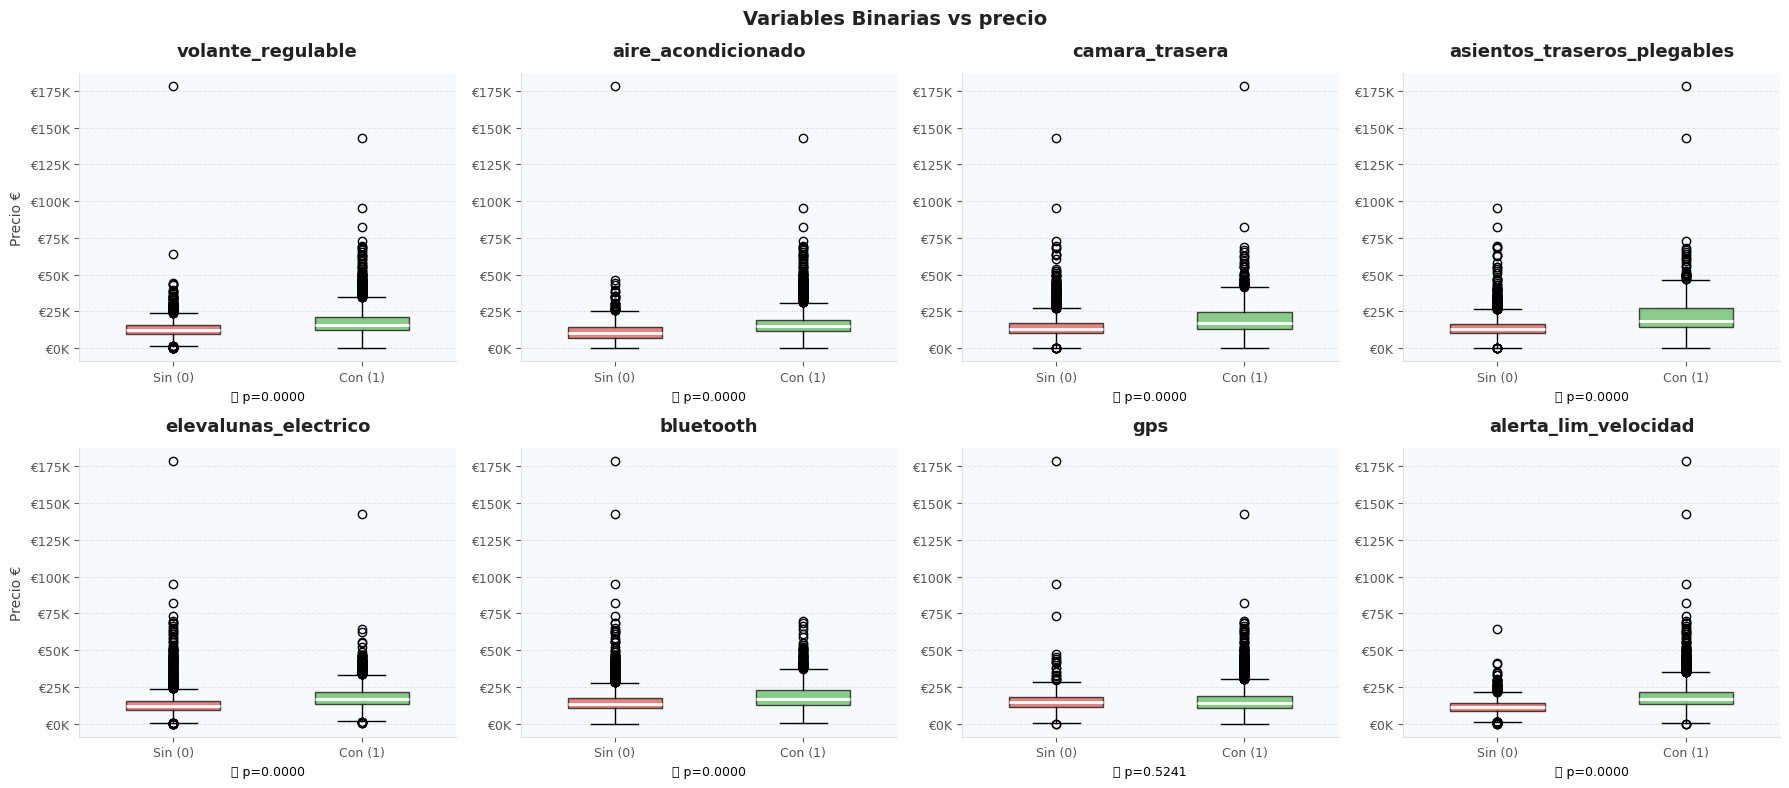

,variable,precio medio sin (0),precio medio con (1),diferencia,p-valor ANOVA,significativa
0,volante_regulable,"13,109","18,048","+€4,938",0.00,✅ Sí
1,aire_acondicionado,"11,467","16,824","+€5,357",0.00,✅ Sí
2,camara_trasera,"14,661","20,446","+€5,785",0.00,✅ Sí
3,asientos_traseros_plegables,"14,114","22,004","+€7,891",0.00,✅ Sí
4,elevalunas_electrico,"13,590","18,446","+€4,856",0.00,✅ Sí
5,bluetooth,"14,949","19,193","+€4,244",0.00,✅ Sí
6,gps,"16,141","15,804",€-336,0.52,❌ No
7,alerta_lim_velocidad,"11,411","18,862","+€7,450",0.00,✅ Sí


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('white')
axes = axes.flatten()

bivar_bin = []
for i, col in enumerate(bin_vars):
    g0 = df[df[col]==0]['precio'].dropna()
    g1 = df[df[col]==1]['precio'].dropna()
    bp = axes[i].boxplot([g0, g1], labels=['Sin (0)', 'Con (1)'],
                         patch_artist=True, widths=0.5,
                         medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#d9534f'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#5cb85c'); bp['boxes'][1].set_alpha(0.7)
    apply_style(axes[i], title=col, ylabel='Precio €' if i%4==0 else '')
    axes[i].yaxis.set_major_formatter(fmt_k)
    if len(g0)>1 and len(g1)>1:
        f, p = stats.f_oneway(g0, g1)
        dif  = g1.mean() - g0.mean()
        axes[i].set_xlabel(f'{"✅" if p<0.05 else "❌"} p={p:.4f}', fontsize=9)
        bivar_bin.append({'variable': col,
                          'precio medio sin (0)': round(g0.mean()),
                          'precio medio con (1)': round(g1.mean()),
                          'diferencia':           f"{'+'if dif>0 else ''}€{dif:,.0f}",
                          'p-valor ANOVA':        round(p,4),
                          'significativa':        '✅ Sí' if p<0.05 else '❌ No'})

plt.suptitle('Variables Binarias vs precio', fontsize=14, fontweight='bold', color='#222')
plt.tight_layout()
plt.savefig('bivar_binarias.png', dpi=130, bbox_inches='tight')
plt.show()
display(pretty_table(pd.DataFrame(bivar_bin), precision=2))


### 11.4 ANOVA Multivariante

In [ ]:
print("ANOVA Tipo II: precio ~ tipo_coche + tipo_gasolina + color")
print("="*60)
_ = test_anova(df, 'precio', ['precio', 'tipo_coche', 'tipo_gasolina', 'color'])


ANOVA Tipo II: precio ~ tipo_coche + tipo_gasolina + color


,variable,sum_sq,df,F,p-value,significativa
0,tipo_coche,"58,425,056,922.000",7,117.490,0.000,✅ Sí
1,tipo_gasolina,"3,727,343,677.000",3,17.490,0.000,✅ Sí
2,color,"2,527,000,350.000",9,3.950,0.000,✅ Sí



R² global del modelo: 16.13%


## 12. Transformación de Categóricas a Numéricas

| Variable | Cardinalidad | Técnica | Justificación |
|---|---|---|---|
| `tipo_coche` | 8 | **One-Hot Encoding** | Baja cardinalidad, sin orden natural |
| `tipo_gasolina` | 4 | **One-Hot Encoding** | Categorías nominales |
| `color` | 10 | **One-Hot Encoding** | Baja-media cardinalidad |
| `modelo` | 76 | **Target Encoding suavizado** | Alta cardinalidad — OHE generaría 75 columnas dispersas |


In [ ]:
df_enc = df.copy()

# ── One-Hot Encoding ────────────────────────────────────
ohe_cols = ['tipo_coche', 'tipo_gasolina', 'color', 'serie']
df_enc   = pd.get_dummies(df_enc, columns=ohe_cols, drop_first=True, dtype=int)
print(f"Columnas tras OHE: {df_enc.shape[1]}")


Columnas tras OHE: 48


In [ ]:
# ── Target Encoding suavizado para 'modelo' ─────────────
global_mean = df_enc['precio'].mean()
K = 10

stats_modelo = (df_enc.groupby('modelo', observed=True)['precio']
                      .agg(['mean','count']).reset_index())
stats_modelo.columns = ['modelo', 'precio_medio', 'n']
stats_modelo['modelo_te'] = (
    (stats_modelo['n'] * stats_modelo['precio_medio'] + K * global_mean) /
    (stats_modelo['n'] + K)
)
stats_modelo_show = stats_modelo.sort_values('precio_medio', ascending=False).head(15).reset_index(drop=True)
display(pretty_table(stats_modelo_show, precision=1))

df_enc = df_enc.merge(stats_modelo[['modelo','modelo_te']], on='modelo', how='left')
df_enc = df_enc.drop(columns=['modelo'])
print(f"\n✅ Shape final tras encoding: {df_enc.shape}")


,modelo,precio_medio,n,modelo_te
0,i8,"95,200.0",1,"23,042.8"
1,M4,"61,650.0",2,"23,464.3"
2,X6 M,"51,050.0",8,"31,481.7"
3,X5 M50,"49,533.3",3,"23,605.5"
4,M5,"41,600.0",1,"18,170.1"
5,X5 M,"37,788.2",17,"29,654.5"
6,740,"37,772.2",18,"29,934.7"
7,750,"37,200.0",2,"19,389.3"
8,640 Gran Coupé,"37,066.7",18,"29,481.1"
9,M3,"36,428.6",7,"24,310.1"



✅ Shape final tras encoding: (4817, 48)


## 13. Escalado (MinMaxScaler) y Correlación Final

In [ ]:
from sklearn.preprocessing import MinMaxScaler

X = df_enc.drop(columns=['precio', 'log_precio'])
y = df_enc['precio']

scaler     = MinMaxScaler()
cols_scale = X.select_dtypes(include=[np.number]).columns.tolist()
X_sc       = X.copy()
X_sc[cols_scale] = scaler.fit_transform(X[cols_scale].astype(float))

print(f"Features escaladas: {len(cols_scale)}")
display(pretty_table(X_sc[cols_scale[:6]].describe().T.reset_index().rename(columns={'index':'variable'}), precision=4))


Features escaladas: 46


,variable,count,mean,std,min,25%,50%,75%,max
0,km,"4,817.0000",0.1405,0.0602,0.0000,0.1024,0.1406,0.1748,1.0000
1,potencia,"4,817.0000",0.3049,0.0921,0.0000,0.2364,0.2837,0.3191,1.0000
2,volante_regulable,"4,817.0000",0.5503,0.4975,0.0000,0.0000,1.0000,1.0000,1.0000
3,aire_acondicionado,"4,817.0000",0.8140,0.3892,0.0000,1.0000,1.0000,1.0000,1.0000
4,camara_trasera,"4,817.0000",0.2016,0.4012,0.0000,0.0000,0.0000,0.0000,1.0000
5,asientos_traseros_plegables,"4,817.0000",0.2171,0.4123,0.0000,0.0000,0.0000,0.0000,1.0000


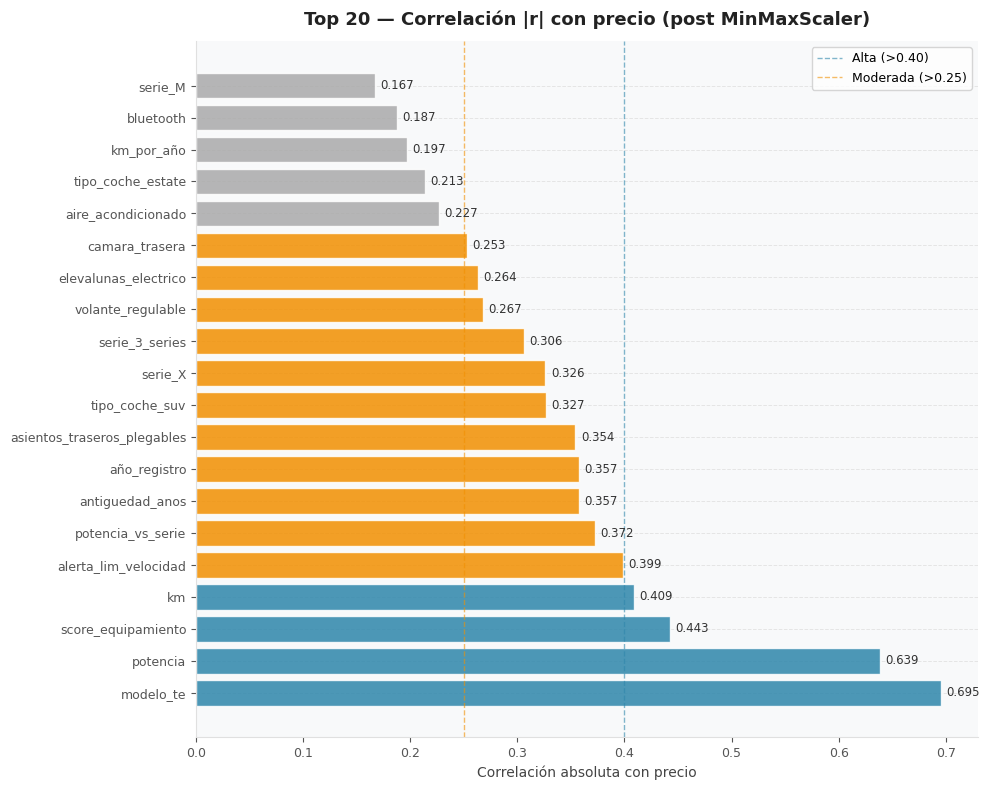

In [ ]:
# ── Correlación final con precio ─────────────────────────
df_fc = X_sc.copy()
df_fc['precio'] = y.values

corr_fin = df_fc.astype(float).corr()['precio'].drop('precio').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
top20  = corr_fin.head(20)
c_bars = [PALETTE[0] if v > 0.4 else PALETTE[2] if v > 0.25 else '#AAAAAA' for v in top20.values]

bars = ax.barh(range(len(top20)), top20.values, color=c_bars, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
for bar, val in zip(bars, top20.values):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5, color='#333')
ax.axvline(0.40, color=PALETTE[0], linestyle='--', linewidth=1, alpha=0.6, label='Alta (>0.40)')
ax.axvline(0.25, color=PALETTE[2], linestyle='--', linewidth=1, alpha=0.6, label='Moderada (>0.25)')
ax.legend(fontsize=9)
apply_style(ax, title='Top 20 — Correlación |r| con precio (post MinMaxScaler)',
            xlabel='Correlación absoluta con precio')
plt.tight_layout()
plt.savefig('correlacion_final.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
corr_tabla = (corr_fin.head(15)
               .reset_index()
               .rename(columns={'index':'variable', 'precio':'|r| con precio'}))
corr_tabla['nivel'] = corr_tabla['|r| con precio'].apply(
    lambda v: '🔵 Alta' if v>0.4 else '🟡 Moderada' if v>0.25 else '⚪ Baja')
display(pretty_table(corr_tabla, precision=4))


,variable,|r| con precio,nivel
0,modelo_te,0.6955,🔵 Alta
1,potencia,0.6386,🔵 Alta
2,score_equipamiento,0.4429,🔵 Alta
3,km,0.4089,🔵 Alta
4,alerta_lim_velocidad,0.3986,🟡 Moderada
5,potencia_vs_serie,0.3721,🟡 Moderada
6,antiguedad_anos,0.3574,🟡 Moderada
7,año_registro,0.3574,🟡 Moderada
8,asientos_traseros_plegables,0.3542,🟡 Moderada
9,tipo_coche_suv,0.3268,🟡 Moderada


In [ ]:
# ── Multicolinealidad ─────────────────────────────────────
corr_X = X_sc.astype(float).corr().abs()
mc_rows = [(corr_X.columns[i], corr_X.columns[j], round(corr_X.iloc[i,j],3))
           for i in range(len(corr_X))
           for j in range(i+1, len(corr_X))
           if corr_X.iloc[i,j] > 0.85]

if mc_rows:
    mc_df = pd.DataFrame(mc_rows, columns=['variable A','variable B','r']).sort_values('r', ascending=False)
    mc_df['acción'] = 'Evaluar VIF — considerar eliminar una'
    print("⚠️  Pares con posible multicolinealidad (r > 0.85):")
    display(pretty_table(mc_df, precision=3))
else:
    print("✅ Sin multicolinealidad crítica detectada (r > 0.85)")


⚠️  Pares con posible multicolinealidad (r > 0.85):


,variable A,variable B,r,acción
0,año_registro,antiguedad_anos,1.000,Evaluar VIF — considerar eliminar una
1,tipo_coche_suv,serie_X,0.998,Evaluar VIF — considerar eliminar una


In [ ]:
# ── Decisión de multicolinealidad: eliminar año_registro ─────────────────────
# año_registro y antiguedad_anos tienen r ≈ -0.99 entre sí (misma información,
# signo invertido). Se conserva antiguedad_anos porque:
#   - Es más directamente interpretable (número de años de antigüedad)
#   - En la correlación con precio su |r| es equivalente o superior
r_anio  = corr_fin.get('año_registro',  pd.Series([0])).iloc[0] if hasattr(corr_fin.get('año_registro', 0), 'iloc') else corr_fin.get('año_registro', 0)
r_antig = corr_fin.get('antiguedad_anos', pd.Series([0])).iloc[0] if hasattr(corr_fin.get('antiguedad_anos', 0), 'iloc') else corr_fin.get('antiguedad_anos', 0)

print(f"  |r| año_registro    ↔ precio : {r_anio:.4f}")
print(f"  |r| antiguedad_anos ↔ precio : {r_antig:.4f}")
print(f"  → Se elimina 'año_registro' de X_sc.")

cols_to_drop = [c for c in ['año_registro', 'modelo'] if c in X_sc.columns]
if cols_to_drop:
    print(f"  Columnas eliminadas de X_sc: {cols_to_drop}")
    print(f"  ('modelo' string fue reemplazado por 'modelo_te'; no debe entrar en vfin.)")
    X_sc = X_sc.drop(columns=cols_to_drop)

print(f"\nShape X_sc final: {X_sc.shape[0]:,} filas × {X_sc.shape[1]} columnas")
print(f"Tipos no numéricos restantes: {list(X_sc.select_dtypes(exclude='number').columns)}")

  |r| año_registro    ↔ precio : 0.3574
  |r| antiguedad_anos ↔ precio : 0.3574
  → Se elimina 'año_registro' de X_sc.
  Columnas eliminadas de X_sc: ['año_registro']
  ('modelo' string fue reemplazado por 'modelo_te'; no debe entrar en vfin.)

Shape X_sc final: 4,817 filas × 45 columnas
Tipos no numéricos restantes: []


## 14. DataFrame Final `vfin`

In [ ]:
vfin = X_sc.copy()
vfin['precio'] = y.values

# Garantizar que TODAS las columnas sean numéricas (float64)
for col in vfin.columns:
    try:
        vfin[col] = vfin[col].astype(float)
    except (ValueError, TypeError):
        print(f"  ⚠️  {col} no se pudo convertir a float — se elimina de vfin")
        vfin = vfin.drop(columns=[col])

non_numeric = list(vfin.select_dtypes(exclude='number').columns)
if non_numeric:
    print(f"⚠️  Columnas no numéricas restantes: {non_numeric}")
else:
    print("✅ Todas las columnas de vfin son numéricas (float64)")

print(f"Shape: {vfin.shape[0]:,} filas × {vfin.shape[1]} columnas")
print(f"Nulos: {vfin.isnull().sum().sum()}")
vfin.info()

✅ Todas las columnas de vfin son numéricas (float64)
Shape: 4,817 filas × 46 columnas
Nulos: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4817 entries, 0 to 4816
Data columns (total 46 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   km                           4817 non-null   float64
 1   potencia                     4817 non-null   float64
 2   volante_regulable            4817 non-null   float64
 3   aire_acondicionado           4817 non-null   float64
 4   camara_trasera               4817 non-null   float64
 5   asientos_traseros_plegables  4817 non-null   float64
 6   elevalunas_electrico         4817 non-null   float64
 7   bluetooth                    4817 non-null   float64
 8   gps                          4817 non-null   float64
 9   alerta_lim_velocidad         4817 non-null   float64
 10  antiguedad_anos              4817 non-null   float64
 11  score_equipamiento           4817 non-n

In [ ]:
# Tabla resumen del dataframe final
origen_map = {
    'precio': 'Target (sin escalar)', 'km': 'Numérica original',
    'potencia': 'Numérica original', 'año_registro': 'Extraída de fecha_registro',
    'antiguedad_anos': 'Derivada (2018 − año_registro)',
    'modelo_te': 'Target Encoding suavizado (modelo)',
}
resumen_vfin = pd.DataFrame([{
    '#': i+1, 'columna': col, 'dtype': str(vfin[col].dtype),
    'min': round(vfin[col].min(), 3), 'max': round(vfin[col].max(), 3),
    'origen': origen_map.get(col,
              'OHE' if any(k in col for k in ['tipo_coche_','tipo_gasolina_','color_'])
              else 'Binaria (0/1)')
} for i, col in enumerate(vfin.columns)])

display(pretty_table(resumen_vfin, precision=3))


,#,columna,dtype,min,max,origen
0,1,km,float64,0.000,1.000,Numérica original
1,2,potencia,float64,0.000,1.000,Numérica original
2,3,volante_regulable,float64,0.000,1.000,Binaria (0/1)
3,4,aire_acondicionado,float64,0.000,1.000,Binaria (0/1)
4,5,camara_trasera,float64,0.000,1.000,Binaria (0/1)
5,6,asientos_traseros_plegables,float64,0.000,1.000,Binaria (0/1)
6,7,elevalunas_electrico,float64,0.000,1.000,Binaria (0/1)
7,8,bluetooth,float64,0.000,1.000,Binaria (0/1)
8,9,gps,float64,0.000,1.000,Binaria (0/1)
9,10,alerta_lim_velocidad,float64,0.000,1.000,Binaria (0/1)


In [ ]:
print("Primeras 5 filas de vfin:")
display(pretty_table(vfin.head(), precision=4))


Primeras 5 filas de vfin:


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,antiguedad_anos,score_equipamiento,km_por_año,potencia_vs_serie,tipo_coche_coupe,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,color_black,color_blue,color_brown,color_green,color_grey,color_orange,color_red,color_silver,color_white,serie_2_series,serie_3_series,serie_4_series,serie_5_series,serie_6_series,serie_7_series,serie_M,serie_X,serie_Z,serie_i,serie_other,modelo_te,precio
0,0.1399,0.2364,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.1852,0.5714,0.3764,0.3448,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0106,"11,300.0000"
1,0.0135,0.7494,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0741,0.7143,0.0731,0.3940,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.6299,"69,700.0000"
2,0.1828,0.2837,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.1852,0.2857,0.4920,0.3421,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1115,"10,200.0000"
3,0.1276,0.3191,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.1111,0.8571,0.5156,0.2933,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5858,"25,100.0000"
4,0.0966,0.3783,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.1481,0.7143,0.3120,0.3626,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3940,"33,400.0000"


### Data Leakage — Análisis

Se distinguen dos tipos de riesgo de leakage en este pipeline:

| Tipo | Variable | Riesgo | Acción |
|------|----------|--------|--------|
| **Target leakage** | `modelo_te` | ⚠️ MODERADO — el Target Encoding usa `precio` calculado sobre todo el dataset | Aplicar TE dentro de CV (k-fold) en modelado; en EDA es aceptable |
| **Target leakage** | `potencia_vs_serie` | ⚠️ BAJO — media de potencia por serie, no directamente el target | Sin acción requerida en EDA |
| **Temporal leakage** | `antiguedad_anos`, `km`, `potencia` | ✅ NINGUNO — son propiedades del vehículo conocidas al momento de la venta | — |
| **Train-test leakage** | MinMaxScaler | ⚠️ POTENCIAL — scaler ajustado sobre todo el dataset | Re-fitear solo sobre train en modelado final |
| **Columna eliminada** | `año_registro` | ✅ RESUELTO — multicolinealidad r≈−0.99 con `antiguedad_anos` | Eliminada |

In [ ]:
# ── Cuantificación del riesgo de leakage de modelo_te ────────────────────────
# El Target Encoding usa precio del dataset completo → el precio ya visto
# influye en la feature. Medimos el "optimismo" comparando:
#   1. r(modelo_te, precio) en el dataset completo
#   2. r(modelo_te, precio) usando leave-one-out TE (aproximación)

from sklearn.model_selection import KFold

def target_encode_cv(df_local, col, target, n_splits=5, smoothing=10):
    """Target Encoding cross-validado (evita leakage)."""
    global_mean = df_local[target].mean()
    te_cv = np.full(len(df_local), np.nan)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(df_local):
        train_ = df_local.iloc[train_idx]
        stats_ = (train_.groupby(col, observed=True)[target]
                  .agg(['mean','count']).reset_index())
        stats_['te'] = (stats_['count']*stats_['mean'] + smoothing*global_mean) / (stats_['count'] + smoothing)
        lookup = dict(zip(stats_[col], stats_['te']))
        for idx in val_idx:
            te_cv[idx] = lookup.get(df_local[col].iloc[idx], global_mean)
    return te_cv

# Necesitamos el modelo original (antes del OHE) junto con precio
df_leakage = df[['modelo','precio']].dropna()
te_full = df_leakage.groupby('modelo', observed=True)['precio'].transform(
    lambda x: (len(x)*x.mean() + 10*df_leakage['precio'].mean()) / (len(x)+10))
te_cv_vals = target_encode_cv(df_leakage.reset_index(drop=True), 'modelo', 'precio')

r_full, _ = stats.pearsonr(te_full, df_leakage['precio'])
r_cv,   _ = stats.pearsonr(te_cv_vals, df_leakage['precio'])
optimism = r_full - r_cv

print("Data leakage — Target Encoding de 'modelo':")
print(f"  r(modelo_te_full, precio) = {r_full:.4f}  ← contiene leakage")
print(f"  r(modelo_te_CV,  precio) = {r_cv:.4f}  ← estimación honesta (5-fold)")
print(f"  Optimismo = {optimism:.4f} ({optimism/r_full*100:.1f}% de inflación)")
if optimism < 0.05:
    print("  ✅ Riesgo BAJO: inflación < 5 puntos — el TE es estable.")
else:
    print("  ⚠️  Riesgo MODERADO: re-fitear TE dentro del loop de CV en modelado final.")

print()
print("MinMaxScaler leakage:")
print("  ⚠️  El scaler fue ajustado sobre TODO el dataset.")
print("  → En el pipeline de modelado, usar Pipeline(scaler + modelo) con CV.")
print("     Para este EDA el impacto es mínimo (solo afecta la escala, no la correlación).")

Data leakage — Target Encoding de 'modelo':
  r(modelo_te_full, precio) = 0.6955  ← contiene leakage
  r(modelo_te_CV,  precio) = 0.6728  ← estimación honesta (5-fold)
  Optimismo = 0.0226 (3.3% de inflación)
  ✅ Riesgo BAJO: inflación < 5 puntos — el TE es estable.

MinMaxScaler leakage:
  ⚠️  El scaler fue ajustado sobre TODO el dataset.
  → En el pipeline de modelado, usar Pipeline(scaler + modelo) con CV.
     Para este EDA el impacto es mínimo (solo afecta la escala, no la correlación).


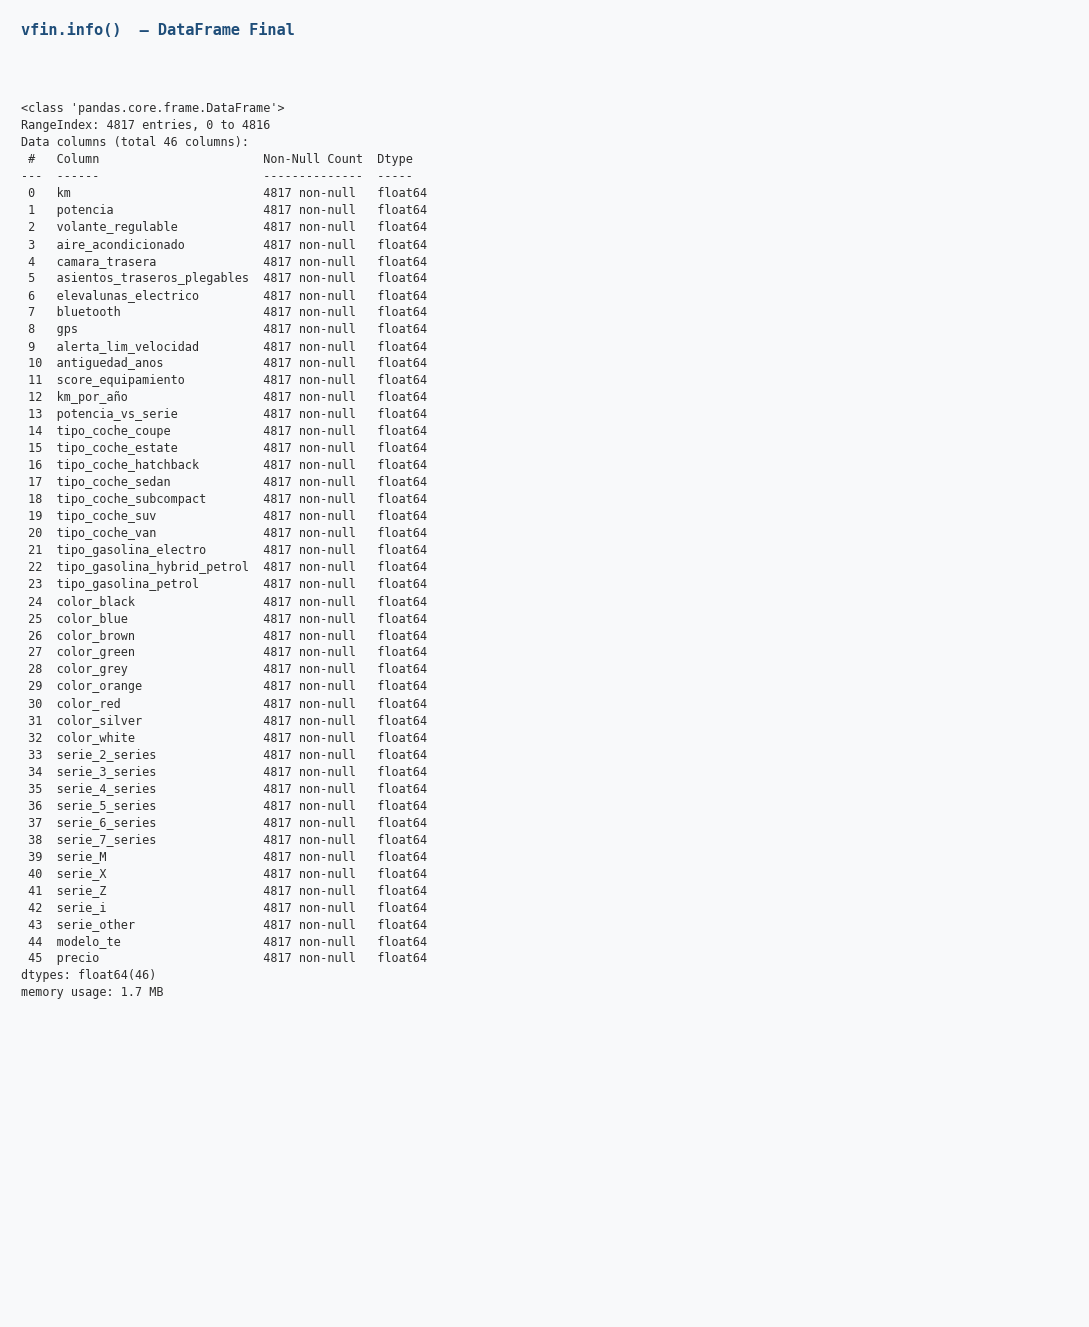

✅ Imagen guardada como 'vfin_info.png'


In [ ]:
# ── Exportar vfin.info() como imagen PNG ─────────────────────────────────────
import io, textwrap

buf = io.StringIO()
vfin.info(buf=buf, verbose=True, show_counts=True)
info_str = buf.getvalue()

lines = info_str.split('\n')
fig_h = max(6, len(lines) * 0.22 + 1.5)
fig, ax = plt.subplots(figsize=(11, fig_h))
fig.patch.set_facecolor('#F8F9FA')
ax.axis('off')

ax.text(0.01, 0.99, 'vfin.info()  — DataFrame Final',
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        va='top', ha='left', color='#1F4E79',
        fontfamily='monospace')
ax.text(0.01, 0.93, info_str,
        transform=ax.transAxes, fontsize=8.5,
        va='top', ha='left', color='#2D2D2D',
        fontfamily='monospace',
        linespacing=1.4)

plt.tight_layout()
plt.savefig('vfin_info.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Imagen guardada como 'vfin_info.png'")

In [ ]:
# ── Exportar primeras 50 filas a Excel ───────────────────────────────────────
output_excel = 'vfin_primeras_50_filas.xlsx'

vfin.head(50).to_excel(output_excel, index=False, sheet_name='vfin_50')
print(f"✅ Excel exportado: '{output_excel}'")
print(f"   Filas: 50  |  Columnas: {vfin.shape[1]}")

✅ Excel exportado: 'vfin_primeras_50_filas.xlsx'
   Filas: 50  |  Columnas: 46


## 15. Resumen del Proceso

| Paso | Descripción | Resultado |
|---|---|---|
| 1 | Carga del dataset | 4.843 filas × 18 columnas |
| 2 | Eliminación de columnas | `marca` (sin varianza) + `fecha_venta` (99.9% = 2018) |
| 3 | Conversión de booleanas | 8 variables bool → int (0/1) |
| 4 | Limpieza adicional | km negativo corregido, tipo_gasolina normalizado |
| 5 | Manejo de fechas | `fecha_registro` → `año_registro` + `antiguedad_anos` |
| 6 | Imputación en orden óptimo | 0 nulos restantes |
| 7 | EDA univariado | Distribuciones, outliers, estadísticas por variable |
| 8 | Correlación inicial | Pearson + V de Cramér |
| 9 | EDA bivariado | Scatter, boxplot, ANOVA individual y multivariante |
| 10 | Encoding | OHE (tipo_coche, tipo_gasolina, color) + Target Encoding (modelo) |
| 11 | Escalado | MinMaxScaler → rango [0, 1] en todas las features |
| 12 | Correlación final | Ranking de features predictivas del precio |

### Top hallazgos
- **`potencia`** — correlación más alta con precio: r = +0.639
- **`km`** — correlación negativa más fuerte: r = −0.410
- **`modelo_te`** — captura la mayor parte de la varianza explicada por el modelo del auto
- **`precio`** tiene skewness = 3.32 → usar **log(precio)** como target en modelos lineales
- **`gps`** — correlación prácticamente nula con precio (r = −0.005); candidato a eliminación
- **`asientos_traseros_plegables`** — 70% imputado; usar con cautela en el modelado
